Single-Depot Split-Delivery Vehicle Routing Problem (SDVRP)

This model uses one MILP optimization to determine the best set of multiple truck routes from the Karatina depot to all 7 factories.

The model simultaneously decides truck routes, stop sequences, and fertilizer quantities delivered, while satisfying:

10-tonne truck capacity
Full factory demand
8-hour maximum route time
Split deliveries
Multi-stop routes
Return to Karatina after each trip

Objective: Minimize fertilizer transport cost based on actual load carried on each road segment.

Cost = KSh 16 × tonne-kilometres

The model is solved using PuLP/CBC and the resulting routes are independently validated for demand, capacity, time, load conservation, and cost.

In [ ]:
import math
import time
import pandas as pdc
import pulp
print("=" * 100)
print("QSOLVE CLASSICAL BASELINE - 7 FACTORY SDVRP")
print("SINGLE DEPOT + SPLIT DELIVERY + MULTI-STOP ROUTING")
print("=" * 100)


# ============================================================
# 1. BASIC DATA
# ============================================================

DEPOT = "Karatina"

FACTORIES = [
    "Mukangu",
    "Ragati",
    "Chema",
    "Kianjega",
    "Nguguini",
    "Kiangai",
    "Thunguri"
]

NODES = [DEPOT] + FACTORIES


# ============================================================
# 2. FACTORY DEMAND
#    tonnes
# ============================================================

DEMAND = {

    "Ragati": 28.380,

    "Nguguini": 73.092,

    "Kiangai": 36.489,

    "Thunguri": 37.170,

    "Kianjega": 24.522,

    "Chema": 10.848,

    "Mukangu": 23.199

}


# ============================================================
# 3. DEPOT AND VEHICLE INFORMATION
# ============================================================

DEPOT_STOCK = 410.000

TRUCK_CAPACITY = 10.000

COST_PER_TONNE_KM = 16.0

MAX_ROUTE_HOURS = 8.0


# ============================================================
# 4. NUMERICAL PARAMETERS
# ============================================================

EPS = 1e-6

# 0.01 tonne = 10 kg
#
# This prevents meaningless numerical stops such as
# 0.001 tonne.
#
# It is a numerical/operational threshold, not an official
# factory minimum order quantity.
MIN_DELIVERY = 0.01


# ============================================================
# 5. CALCULATE TOTAL DEMAND AND MINIMUM NUMBER OF TRIPS
# ============================================================

TOTAL_DEMAND = sum(
    DEMAND[f]
    for f in FACTORIES
)

MIN_TRIPS = math.ceil(
    TOTAL_DEMAND / TRUCK_CAPACITY
)

# For this problem:
#
# 233.7 / 10 = 23.37
#
# therefore:
#
# MIN_TRIPS = 24

NUM_TRUCKS = MIN_TRIPS


print("\n")
print("=" * 100)
print("PROBLEM DATA")
print("=" * 100)

print(
    f"Total factory demand : "
    f"{TOTAL_DEMAND:.3f} tonnes"
)

print(
    f"Depot stock          : "
    f"{DEPOT_STOCK:.3f} tonnes"
)

print(
    f"Truck capacity       : "
    f"{TRUCK_CAPACITY:.3f} tonnes"
)

print(
    f"Transport cost       : "
    f"KSh {COST_PER_TONNE_KM:.2f}/tonne-km"
)

print(
    f"Minimum truck trips  : "
    f"{MIN_TRIPS}"
)

print(
    f"Maximum route time   : "
    f"{MAX_ROUTE_HOURS:.2f} hours"
)


# ============================================================
# 6. ROAD DISTANCES
#    kilometres
# ============================================================

DISTANCE_INPUT = {

    # ----------------------------
    # Karatina -> factories
    # ----------------------------

    ("Karatina", "Ragati"): 11.82,
    ("Karatina", "Nguguini"): 18.92,
    ("Karatina", "Kiangai"): 20.02,
    ("Karatina", "Thunguri"): 23.13,
    ("Karatina", "Kianjega"): 13.11,
    ("Karatina", "Chema"): 11.95,
    ("Karatina", "Mukangu"): 10.08,

    # ----------------------------
    # Factory -> factory
    # ----------------------------

    ("Ragati", "Nguguini"): 15.86,
    ("Ragati", "Kiangai"): 29.64,
    ("Ragati", "Thunguri"): 34.81,
    ("Ragati", "Kianjega"): 25.51,
    ("Ragati", "Chema"): 11.53,
    ("Ragati", "Mukangu"): 21.86,

    ("Nguguini", "Kiangai"): 19.08,
    ("Nguguini", "Thunguri"): 40.65,
    ("Nguguini", "Kianjega"): 20.23,
    ("Nguguini", "Chema"): 9.84,
    ("Nguguini", "Mukangu"): 24.95,

    ("Kiangai", "Thunguri"): 38.90,
    ("Kiangai", "Kianjega"): 7.71,
    ("Kiangai", "Chema"): 21.17,
    ("Kiangai", "Mukangu"): 21.38,

    ("Thunguri", "Kianjega"): 32.26,
    ("Thunguri", "Chema"): 33.69,
    ("Thunguri", "Mukangu"): 24.62,

    ("Kianjega", "Chema"): 19.38,
    ("Kianjega", "Mukangu"): 14.75,

    ("Chema", "Mukangu"): 18.26
}


# ============================================================
# 7. CONSTRUCT SYMMETRIC ROAD DISTANCE MATRIX
# ============================================================

D = {}

for i in NODES:

    for j in NODES:

        if i == j:

            D[i, j] = 0.0

        elif (i, j) in DISTANCE_INPUT:

            D[i, j] = DISTANCE_INPUT[i, j]

        elif (j, i) in DISTANCE_INPUT:

            D[i, j] = DISTANCE_INPUT[j, i]

        else:

            raise ValueError(
                f"Missing road distance between "
                f"{i} and {j}"
            )


# ============================================================
# 8. TRAVEL TIMES
#    hours
# ============================================================

TIME_INPUT = {

    # ----------------------------
    # Karatina -> factories
    # ----------------------------

    ("Karatina", "Ragati"): 0.27,
    ("Karatina", "Nguguini"): 0.44,
    ("Karatina", "Kiangai"): 0.29,
    ("Karatina", "Thunguri"): 0.52,
    ("Karatina", "Kianjega"): 0.14,
    ("Karatina", "Chema"): 0.28,
    ("Karatina", "Mukangu"): 0.22,

    # ----------------------------
    # Factory -> factory
    # ----------------------------

    ("Ragati", "Nguguini"): 0.38,
    ("Ragati", "Kiangai"): 0.55,
    ("Ragati", "Thunguri"): 0.79,
    ("Ragati", "Kianjega"): 0.42,
    ("Ragati", "Chema"): 0.28,
    ("Ragati", "Mukangu"): 0.47,

    ("Nguguini", "Kiangai"): 0.44,
    ("Nguguini", "Thunguri"): 0.92,
    ("Nguguini", "Kianjega"): 0.43,
    ("Nguguini", "Chema"): 0.23,
    ("Nguguini", "Mukangu"): 0.57,

    ("Kiangai", "Thunguri"): 0.79,
    ("Kiangai", "Kianjega"): 0.15,
    ("Kiangai", "Chema"): 0.51,
    ("Kiangai", "Mukangu"): 0.43,

    ("Thunguri", "Kianjega"): 0.63,
    ("Thunguri", "Chema"): 0.75,
    ("Thunguri", "Mukangu"): 0.56,

    ("Kianjega", "Chema"): 0.35,
    ("Kianjega", "Mukangu"): 0.28,

    ("Chema", "Mukangu"): 0.41
}


# ============================================================
# 9. CONSTRUCT SYMMETRIC TIME MATRIX
# ============================================================

T = {}

for i in NODES:

    for j in NODES:

        if i == j:

            T[i, j] = 0.0

        elif (i, j) in TIME_INPUT:

            T[i, j] = TIME_INPUT[i, j]

        elif (j, i) in TIME_INPUT:

            T[i, j] = TIME_INPUT[j, i]

        else:

            raise ValueError(
                f"Missing travel time between "
                f"{i} and {j}"
            )


# ============================================================
# 10. ROAD ACCESSIBILITY
#
# At present, all supplied matrix arcs are allowed.
#
# If OSM identifies a prohibited road movement, remove that
# pair from ALLOWED_ARCS.
# ============================================================

ALLOWED_ARCS = {

    (i, j)

    for i in NODES

    for j in NODES

    if i != j

}


# ============================================================
# 11. INPUT VALIDATION
# ============================================================

print("\n")
print("=" * 100)
print("INPUT VALIDATION")
print("=" * 100)


# Demand
for factory in FACTORIES:

    if DEMAND[factory] < 0:

        raise ValueError(
            f"Negative demand for {factory}"
        )


# Demand versus depot stock
if TOTAL_DEMAND > DEPOT_STOCK + EPS:

    raise ValueError(
        "Total demand exceeds depot stock."
    )


# Distance matrix
for i in NODES:

    for j in NODES:

        if i == j:
            continue

        if (i, j) not in D:

            raise ValueError(
                f"Missing distance {i} -> {j}"
            )


# Time matrix
for i in NODES:

    for j in NODES:

        if i == j:
            continue

        if (i, j) not in T:

            raise ValueError(
                f"Missing travel time {i} -> {j}"
            )


print("✓ Demand data valid")
print("✓ Depot stock valid")
print("✓ Distance matrix complete")
print("✓ Travel-time matrix complete")
print("✓ Allowed road arcs defined")


# ============================================================
# 12. CREATE MILP MODEL
# ============================================================

model = pulp.LpProblem(
    "QSOLVE_Classical_7Factory_SDVRP",
    pulp.LpMinimize
)


# ============================================================
# 13. DECISION VARIABLES
# ============================================================

# ------------------------------------------------------------
# x[v,i,j]
#
# 1 if truck v travels from node i to node j
# ------------------------------------------------------------

x = {}

for v in range(NUM_TRUCKS):

    for i, j in ALLOWED_ARCS:

        x[v, i, j] = pulp.LpVariable(
            f"x_{v}_{i}_{j}",
            cat="Binary"
        )


# ------------------------------------------------------------
# used[v]
#
# 1 if truck v is used
# ------------------------------------------------------------

used = {}

for v in range(NUM_TRUCKS):

    used[v] = pulp.LpVariable(
        f"used_{v}",
        cat="Binary"
    )


# ------------------------------------------------------------
# visit[v,i]
#
# 1 if truck v visits factory i
# ------------------------------------------------------------

visit = {}

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        visit[v, i] = pulp.LpVariable(
            f"visit_{v}_{i}",
            cat="Binary"
        )


# ------------------------------------------------------------
# q[v,i]
#
# Tonnes delivered by truck v to factory i
# ------------------------------------------------------------

q = {}

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        q[v, i] = pulp.LpVariable(
            f"q_{v}_{i}",
            lowBound=0,
            upBound=DEMAND[i],
            cat="Continuous"
        )


# ------------------------------------------------------------
# load[v,i,j]
#
# Fertilizer tonnes physically carried on arc i -> j
#
# THIS variable determines transport cost.
# ------------------------------------------------------------

load = {}

for v in range(NUM_TRUCKS):

    for i, j in ALLOWED_ARCS:

        load[v, i, j] = pulp.LpVariable(
            f"load_{v}_{i}_{j}",
            lowBound=0,
            upBound=TRUCK_CAPACITY,
            cat="Continuous"
        )


# ------------------------------------------------------------
# order[v,i]
#
# MTZ ordering variable for factory visits.
# ------------------------------------------------------------

order = {}

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        order[v, i] = pulp.LpVariable(
            f"order_{v}_{i}",
            lowBound=0,
            upBound=len(FACTORIES),
            cat="Continuous"
        )


# ============================================================
# 14. OBJECTIVE FUNCTION
#
# Minimize:
#
#   16 KSh × actual tonnes carried × road distance
#
# Empty return:
#
#   load = 0
#
# therefore:
#
#   cost = 0
#
# on the return-to-depot arc.
# ============================================================

model += pulp.lpSum(

    COST_PER_TONNE_KM
    * D[i, j]
    * load[v, i, j]

    for v in range(NUM_TRUCKS)

    for i, j in ALLOWED_ARCS

), "Total_Fertilizer_Tonne_Km_Cost"


# ============================================================
# 15. DEMAND SATISFACTION
#
# Every factory receives exactly its demand.
# ============================================================

for i in FACTORIES:

    model += (

        pulp.lpSum(
            q[v, i]
            for v in range(NUM_TRUCKS)
        )

        == DEMAND[i]

    ), f"Demand_{i}"


# ============================================================
# 16. DEPOT STOCK CONSTRAINT
# ============================================================

model += (

    pulp.lpSum(
        q[v, i]
        for v in range(NUM_TRUCKS)
        for i in FACTORIES
    )

    <= DEPOT_STOCK

), "Depot_Stock"


# ============================================================
# 17. EACH TRUCK'S TOTAL DELIVERED LOAD
#     CANNOT EXCEED CAPACITY
# ============================================================

for v in range(NUM_TRUCKS):

    model += (

        pulp.lpSum(
            q[v, i]
            for i in FACTORIES
        )

        <= TRUCK_CAPACITY * used[v]

    ), f"Truck_Capacity_{v}"


# ============================================================
# 18. EXACTLY 24 ACTIVE TRUCKS
#
# 233.7 tonnes / 10 tonnes = 23.37
#
# Therefore 24 trucks are mathematically necessary.
# ============================================================

model += (

    pulp.lpSum(
        used[v]
        for v in range(NUM_TRUCKS)
    )

    == MIN_TRIPS

), "Minimum_Required_Trips"


# ============================================================
# 19. DEPOT DEPARTURE
#
# Every used truck leaves Karatina exactly once.
# ============================================================

for v in range(NUM_TRUCKS):

    model += (

        pulp.lpSum(
            x[v, DEPOT, j]
            for j in FACTORIES
            if (DEPOT, j) in ALLOWED_ARCS
        )

        == used[v]

    ), f"Depot_Departure_{v}"


# ============================================================
# 20. DEPOT RETURN
#
# Every used truck returns to Karatina exactly once.
# ============================================================

for v in range(NUM_TRUCKS):

    model += (

        pulp.lpSum(
            x[v, i, DEPOT]
            for i in FACTORIES
            if (i, DEPOT) in ALLOWED_ARCS
        )

        == used[v]

    ), f"Depot_Return_{v}"


# ============================================================
# 21. FACTORY FLOW CONSERVATION
#
# A visited factory has:
#
#   exactly one entering arc
#   exactly one outgoing arc
# ============================================================

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        model += (

            pulp.lpSum(
                x[v, j, i]
                for j in NODES
                if j != i
                and (j, i) in ALLOWED_ARCS
            )

            == visit[v, i]

        ), f"Factory_Entry_{v}_{i}"


        model += (

            pulp.lpSum(
                x[v, i, j]
                for j in NODES
                if j != i
                and (i, j) in ALLOWED_ARCS
            )

            == visit[v, i]

        ), f"Factory_Exit_{v}_{i}"


# ============================================================
# 22. DELIVERY / VISIT LINK
#
# A truck can only deliver where it visits.
# ============================================================

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        model += (

            q[v, i]
            <= DEMAND[i] * visit[v, i]

        ), f"Delivery_Visit_Link_{v}_{i}"


        model += (

            q[v, i]
            >= MIN_DELIVERY * visit[v, i]

        ), f"Minimum_Delivery_{v}_{i}"


# ============================================================
# 23. LOAD CONSERVATION
#
# For each factory:
#
# incoming fertilizer
# -
# outgoing fertilizer
# =
# fertilizer delivered there
#
# Example:
#
# 10 t enters Kiangai
# 6.8 t delivered
# 3.2 t continues to next factory
# ============================================================

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        incoming_load = pulp.lpSum(

            load[v, j, i]

            for j in NODES

            if j != i
            and (j, i) in ALLOWED_ARCS

        )

        outgoing_load = pulp.lpSum(

            load[v, i, j]

            for j in NODES

            if j != i
            and (i, j) in ALLOWED_ARCS

        )

        model += (

            incoming_load
            - outgoing_load

            == q[v, i]

        ), f"Load_Conservation_{v}_{i}"


# ============================================================
# 24. LOAD ONLY ON SELECTED ROAD
# ============================================================

for v in range(NUM_TRUCKS):

    for i, j in ALLOWED_ARCS:

        model += (

            load[v, i, j]

            <= TRUCK_CAPACITY
            * x[v, i, j]

        ), f"Load_Route_Link_{v}_{i}_{j}"


# ============================================================
# 25. PREVENT EMPTY INTER-FACTORY TRAVEL
#

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        for j in FACTORIES:

            if i == j:
                continue

            if (i, j) not in ALLOWED_ARCS:
                continue

            model += (

                load[v, i, j]

                >= MIN_DELIVERY * x[v, i, j]

            ), f"No_Empty_InterFactory_{v}_{i}_{j}"


# ============================================================
# 26. FIRST LEG MUST CARRY FERTILIZER
#
# A truck leaving Karatina must actually carry its delivery.
# ============================================================

for v in range(NUM_TRUCKS):

    model += (

        pulp.lpSum(
            load[v, DEPOT, j]
            for j in FACTORIES
            if (DEPOT, j) in ALLOWED_ARCS
        )

        >= MIN_DELIVERY * used[v]

    ), f"Initial_Load_{v}"


# ============================================================
# 27. DEPOT LOAD BALANCE
#
# Total fertilizer loaded at Karatina equals the total fertilizer
# eventually delivered by that truck.
# ============================================================

for v in range(NUM_TRUCKS):

    outbound_load = pulp.lpSum(

        load[v, DEPOT, j]

        for j in FACTORIES

        if (DEPOT, j) in ALLOWED_ARCS

    )

    return_load = pulp.lpSum(

        load[v, i, DEPOT]

        for i in FACTORIES

        if (i, DEPOT) in ALLOWED_ARCS

    )

    total_delivered = pulp.lpSum(

        q[v, i]

        for i in FACTORIES

    )

    model += (

        outbound_load
        - return_load

        == total_delivered

    ), f"Depot_Load_Balance_{v}"


# ============================================================
# 28. RETURN TO DEPOT MUST BE EMPTY
#
# Once a truck has completed its deliveries, it returns empty.
# ============================================================

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        model += (

            load[v, i, DEPOT]

            == 0

        ), f"Empty_Return_{v}_{i}"


# ============================================================
# 29. ROUTE TIME
#
# Complete physical route:
#
# Karatina -> factories -> Karatina
#
# must not exceed 8 hours.
# ============================================================

for v in range(NUM_TRUCKS):

    model += (

        pulp.lpSum(

            T[i, j] * x[v, i, j]

            for i, j in ALLOWED_ARCS

        )

        <= MAX_ROUTE_HOURS * used[v]

    ), f"Route_Time_{v}"


# ============================================================
# 30. MTZ SUBTOUR ELIMINATION
#
# Prevents disconnected factory-to-factory cycles.
# ============================================================

M = len(FACTORIES)

for v in range(NUM_TRUCKS):

    for i in FACTORIES:

        model += (

            order[v, i]

            <= M * visit[v, i]

        ), f"MTZ_Upper_{v}_{i}"


        model += (

            order[v, i]

            >= visit[v, i]

        ), f"MTZ_Lower_{v}_{i}"


    for i in FACTORIES:

        for j in FACTORIES:

            if i == j:
                continue

            if (i, j) not in ALLOWED_ARCS:
                continue

            model += (

                order[v, i]
                - order[v, j]

                + M * x[v, i, j]

                <= M - 1

            ), f"MTZ_{v}_{i}_{j}"


# ============================================================
# 31. SOLVE MODEL
# ============================================================

print("\n")
print("=" * 100)
print("SOLVING CLASSICAL 7-FACTORY SDVRP")
print("=" * 100)

start_time = time.perf_counter()

solver = pulp.PULP_CBC_CMD(

    msg=True,

    timeLimit=600,

    gapRel=0.001

)

model.solve(solver)

runtime = (
    time.perf_counter()
    - start_time
)

status = pulp.LpStatus[
    model.status
]


# ============================================================
# 32. SOLVER STATUS
# ============================================================

print("\n")
print("=" * 100)
print("SOLVER STATUS")
print("=" * 100)

print(
    f"Status        : {status}"
)

print(
    f"Runtime       : {runtime:.4f} seconds"
)


if status not in ["Optimal", "Feasible"]:

    raise RuntimeError(
        f"No usable solution found. "
        f"Solver status = {status}"
    )


# ============================================================
# 33. FACTORY ALLOCATION
# ============================================================

allocation_records = []

for factory in FACTORIES:

    delivered = sum(

        max(
            0.0,
            pulp.value(
                q[v, factory]
            ) or 0.0
        )

        for v in range(NUM_TRUCKS)

    )

    unmet = max(

        0.0,

        DEMAND[factory]
        - delivered

    )

    fulfillment = (

        100.0
        * delivered
        / DEMAND[factory]

    )

    allocation_records.append({

        "Factory": factory,

        "Demand_tonnes":
            DEMAND[factory],

        "Delivered_tonnes":
            delivered,

        "Unmet_tonnes":
            unmet,

        "Fulfillment_%":
            fulfillment

    })


allocation_df = pd.DataFrame(
    allocation_records
)


# ============================================================
# 34. EXTRACT TRUCK ROUTES
# ============================================================

route_records = []


for v in range(NUM_TRUCKS):

    if pulp.value(
        used[v]
    ) < 0.5:

        continue


    current = DEPOT

    route = [DEPOT]

    visited = set()


    total_distance = 0.0

    total_time = 0.0

    total_tonne_km = 0.0


    # --------------------------------------------------------
    # Follow selected route
    # --------------------------------------------------------

    while True:

        next_node = None

        for j in NODES:

            if j == current:
                continue

            if (
                current,
                j
            ) not in ALLOWED_ARCS:
                continue

            value = pulp.value(
                x[v, current, j]
            )

            if (
                value is not None
                and value > 0.5
            ):

                next_node = j
                break


        if next_node is None:

            raise RuntimeError(

                f"Route for truck {v + 1} "
                f"does not terminate correctly."

            )


        # ----------------------------------------------------
        # Record physical movement
        # ----------------------------------------------------

        total_distance += D[
            current,
            next_node
        ]

        total_time += T[
            current,
            next_node
        ]


        # ----------------------------------------------------
        # Record fertilizer tonne-km on this arc
        # ----------------------------------------------------

        arc_load = pulp.value(

            load[
                v,
                current,
                next_node
            ]

        )

        if arc_load is None:
            arc_load = 0.0


        total_tonne_km += (

            arc_load
            * D[
                current,
                next_node
            ]

        )


        route.append(
            next_node
        )


        # ----------------------------------------------------
        # Return to depot
        # ----------------------------------------------------

        if next_node == DEPOT:

            break


        # ----------------------------------------------------
        # Subtour safety check
        # ----------------------------------------------------

        if next_node in visited:

            raise RuntimeError(

                f"Subtour detected during "
                f"route extraction for truck {v + 1}"

            )


        visited.add(
            next_node
        )

        current = next_node


        if len(route) > len(NODES) + 1:

            raise RuntimeError(
                "Route extraction exceeded expected size."
            )


    # ========================================================
    # TRUCK DELIVERIES
    # ========================================================

    delivery_records = []

    delivered_total = 0.0


    for factory in FACTORIES:

        amount = pulp.value(
            q[v, factory]
        )

        if amount is None:
            amount = 0.0


        if amount > EPS:

            delivery_records.append(
                f"{factory}: {amount:.3f} t"
            )

            delivered_total += amount


    # ========================================================
    # TRUCK INITIAL LOAD
    # ========================================================

    initial_load = sum(

        pulp.value(
            load[
                v,
                DEPOT,
                j
            ]
        ) or 0.0

        for j in FACTORIES

        if (
            DEPOT,
            j
        ) in ALLOWED_ARCS

    )


    # ========================================================
    # TRUCK RECORD
    # ========================================================

    route_records.append({

        "Truck":
            v + 1,

        "Route":
            " -> ".join(route),

        "Stops":
            len(delivery_records),

        "Initial_Load_t":
            initial_load,

        "Delivered_t":
            delivered_total,

        "Remaining_Load_t":
            max(
                0.0,
                initial_load - delivered_total
            ),

        "Distance_km":
            total_distance,

        "Travel_Time_h":
            total_time,

        "Tonne_km":
            total_tonne_km,

        "Cost_KSh":
            COST_PER_TONNE_KM
            * total_tonne_km,

        "Deliveries":
            "; ".join(
                delivery_records
            )

    })


routes_df = pd.DataFrame(
    route_records
)


# ============================================================
# 35. GLOBAL RESULTS
# ============================================================

total_delivered = (
    allocation_df[
        "Delivered_tonnes"
    ].sum()
)

total_unmet = (
    allocation_df[
        "Unmet_tonnes"
    ].sum()
)

total_distance = (
    routes_df[
        "Distance_km"
    ].sum()
)

total_tonne_km = (
    routes_df[
        "Tonne_km"
    ].sum()
)

total_cost = (
    COST_PER_TONNE_KM
    * total_tonne_km
)

used_trucks = len(
    routes_df
)

multi_stop_trips = int(

    (
        routes_df["Stops"] > 1
    ).sum()

)

max_route_time = (
    routes_df[
        "Travel_Time_h"
    ].max()
)

remaining_stock = (
    DEPOT_STOCK
    - total_delivered
)


# ============================================================
# 36. INDEPENDENT COST VALIDATION
# ============================================================

solver_cost = pulp.value(
    model.objective
)

cost_difference = abs(
    total_cost - solver_cost
)

cost_check = (
    cost_difference <= 1e-3
)


# ============================================================
# 37. CAPACITY VALIDATION
# ============================================================

capacity_check = True

for v in range(NUM_TRUCKS):

    truck_total = sum(

        max(
            0.0,
            pulp.value(
                q[v, i]
            ) or 0.0
        )

        for i in FACTORIES
    )

    if (
        truck_total
        > TRUCK_CAPACITY + 1e-4
    ):

        capacity_check = False

        break


# ============================================================
# 38. LOAD-FLOW VALIDATION
# ============================================================

load_flow_check = True

for v in range(NUM_TRUCKS):

    if pulp.value(
        used[v]
    ) < 0.5:

        continue

    total_q = sum(

        max(
            0.0,
            pulp.value(
                q[v, i]
            ) or 0.0
        )

        for i in FACTORIES

    )

    outbound_load = sum(

        max(
            0.0,
            pulp.value(
                load[v, DEPOT, j]
            ) or 0.0
        )

        for j in FACTORIES

    )

    inbound_return = sum(

        max(
            0.0,
            pulp.value(
                load[v, i, DEPOT]
            ) or 0.0
        )

        for i in FACTORIES

    )

    if abs(
        outbound_load
        - inbound_return
        - total_q
    ) > 1e-4:

        load_flow_check = False

        break


# ============================================================
# 39. DEMAND VALIDATION
# ============================================================

demand_check = (

    abs(
        total_delivered
        - TOTAL_DEMAND
    )
    <= 1e-4

)


# ============================================================
# 40. STOCK VALIDATION
# ============================================================

stock_check = (

    total_delivered
    <= DEPOT_STOCK + 1e-4

)


# ============================================================
# 41. ROUTE-TIME VALIDATION
# ============================================================

time_check = True

for _, row in routes_df.iterrows():

    if (
        row["Travel_Time_h"]
        > MAX_ROUTE_HOURS + 1e-6
    ):

        time_check = False

        break


# ============================================================
# 42. EMPTY-RETURN VALIDATION
# ============================================================

empty_return_check = True

for v in range(NUM_TRUCKS):

    if pulp.value(
        used[v]
    ) < 0.5:

        continue


    for i in FACTORIES:

        value = pulp.value(
            load[v, i, DEPOT]
        )

        if (
            value is not None
            and abs(value) > 1e-5
        ):

            empty_return_check = False

            break


# ============================================================
# 43. FINAL RESULTS
# ============================================================

print("\n")
print("=" * 100)
print("FINAL CLASSICAL SDVRP RESULTS")
print("=" * 100)

print(
    f"Solver status             : {status}"
)

print(
    f"Total factories           : {len(FACTORIES)}"
)

print(
    f"Total demand              : "
    f"{TOTAL_DEMAND:.3f} t"
)

print(
    f"Total delivered           : "
    f"{total_delivered:.3f} t"
)

print(
    f"Unmet demand              : "
    f"{total_unmet:.6f} t"
)

print(
    f"Depot stock remaining     : "
    f"{remaining_stock:.3f} t"
)

print(
    f"Minimum required trips   : "
    f"{MIN_TRIPS}"
)

print(
    f"Used trips                : "
    f"{used_trucks}"
)

print(
    f"Multi-stop trips          : "
    f"{multi_stop_trips}"
)

print(
    f"Total vehicle distance    : "
    f"{total_distance:.2f} km"
)

print(
    f"Total fertilizer tonne-km : "
    f"{total_tonne_km:.2f}"
)

print(
    f"Transport cost            : "
    f"KSh {total_cost:,.2f}"
)

print(
    f"Maximum route time        : "
    f"{max_route_time:.2f} h"
)

print(
    f"Solver runtime            : "
    f"{runtime:.4f} s"
)


# ============================================================
# 44. FACTORY ALLOCATION OUTPUT
# ============================================================

print("\n")
print("=" * 100)
print("FACTORY ALLOCATION")
print("=" * 100)

print(

    allocation_df.to_string(

        index=False,

        formatters={

            "Demand_tonnes":
                "{:.3f}".format,

            "Delivered_tonnes":
                "{:.3f}".format,

            "Unmet_tonnes":
                "{:.6f}".format,

            "Fulfillment_%":
                "{:.2f}".format

        }

    )

)


# ============================================================
# 45. ROUTE OUTPUT
# ============================================================

print("\n")
print("=" * 100)
print("OPTIMAL TRUCK ROUTES")
print("=" * 100)

print(

    routes_df.to_string(

        index=False,

        formatters={

            "Initial_Load_t":
                "{:.3f}".format,

            "Delivered_t":
                "{:.3f}".format,

            "Remaining_Load_t":
                "{:.3f}".format,

            "Distance_km":
                "{:.2f}".format,

            "Travel_Time_h":
                "{:.2f}".format,

            "Tonne_km":
                "{:.2f}".format,

            "Cost_KSh":
                "{:,.2f}".format

        }

    )

)


# ============================================================
# 46. VALIDATION OUTPUT
# ============================================================

print("\n")
print("=" * 100)
print("VALIDATION")
print("=" * 100)

print(
    f"Demand fully satisfied : "
    f"{'PASS' if demand_check else 'FAIL'}"
)

print(
    f"Truck capacity         : "
    f"{'PASS' if capacity_check else 'FAIL'}"
)

print(
    f"8-hour route limit     : "
    f"{'PASS' if time_check else 'FAIL'}"
)

print(
    f"Depot stock constraint : "
    f"{'PASS' if stock_check else 'FAIL'}"
)

print(
    f"Load conservation      : "
    f"{'PASS' if load_flow_check else 'FAIL'}"
)

print(
    f"Empty return           : "
    f"{'PASS' if empty_return_check else 'FAIL'}"
)

print(
    f"Cost calculation       : "
    f"{'PASS' if cost_check else 'FAIL'}"
)


all_valid = all([

    demand_check,

    capacity_check,

    time_check,

    stock_check,

    load_flow_check,

    empty_return_check,

    cost_check

])


print("\n")

if all_valid:

    print(
        "✓ ALL CLASSICAL MODEL VALIDATION CHECKS PASS."
    )

else:

    print(
        "✗ ONE OR MORE VALIDATION CHECKS FAILED."
    )


# ============================================================
# 47. COST INTERPRETATION
# ============================================================

print("\n")
print("=" * 100)
print("COST DEFINITION USED")
print("=" * 100)

print(
    "Transport cost = KSh 16 × fertilizer tonne-kilometres."
)

print(
    "Fertilizer tonne-kilometres = "
    "sum(actual fertilizer load on each road segment × "
    "segment distance)."
)

print(
    "The physical return to Karatina is included in route "
    "distance and route time, but carries zero fertilizer, "
    "so it contributes zero tonne-km cost."
)


# ============================================================
# 48. SAVE RESULTS TO EXCEL
# ============================================================

output_file = (
    "QSOLVE_Classical_7Factory_SDVRP_Final.xlsx"
)


summary_df = pd.DataFrame({

    "Metric": [

        "Solver Status",

        "Number of Factories",

        "Total Demand (t)",

        "Total Delivered (t)",

        "Unmet Demand (t)",

        "Depot Stock (t)",

        "Remaining Depot Stock (t)",

        "Truck Capacity (t)",

        "Minimum Trips",

        "Used Trips",

        "Multi-stop Trips",

        "Total Vehicle Distance (km)",

        "Total Fertilizer Tonne-km",

        "Transport Cost (KSh)",

        "Cost Rate (KSh/tonne-km)",

        "Maximum Route Time (h)",

        "Solver Runtime (s)"

    ],

    "Value": [

        status,

        len(FACTORIES),

        TOTAL_DEMAND,

        total_delivered,

        total_unmet,

        DEPOT_STOCK,

        remaining_stock,

        TRUCK_CAPACITY,

        MIN_TRIPS,

        used_trucks,

        multi_stop_trips,

        total_distance,

        total_tonne_km,

        total_cost,

        COST_PER_TONNE_KM,

        max_route_time,

        runtime

    ]

})


validation_df = pd.DataFrame({

    "Validation": [

        "Demand",

        "Truck Capacity",

        "8-Hour Route Limit",

        "Depot Stock",

        "Load Conservation",

        "Empty Return",

        "Cost Calculation"

    ],

    "Result": [

        "PASS" if demand_check else "FAIL",

        "PASS" if capacity_check else "FAIL",

        "PASS" if time_check else "FAIL",

        "PASS" if stock_check else "FAIL",

        "PASS" if load_flow_check else "FAIL",

        "PASS" if empty_return_check else "FAIL",

        "PASS" if cost_check else "FAIL"

    ]

})


with pd.ExcelWriter(

    output_file,

    engine="openpyxl"

) as writer:

    summary_df.to_excel(

        writer,

        sheet_name="Summary",

        index=False

    )

    allocation_df.to_excel(

        writer,

        sheet_name="Factory_Allocation",

        index=False

    )

    routes_df.to_excel(

        writer,

        sheet_name="Truck_Routes",

        index=False

    )

    validation_df.to_excel(

        writer,

        sheet_name="Validation",

        index=False

    )


# ============================================================
# 49. FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 100)
print("RESULTS SAVED")
print("=" * 100)

print(
    f"Excel file: {output_file}"
)

print("=" * 100)

QSOLVE CLASSICAL BASELINE - 7 FACTORY SDVRP
SINGLE DEPOT + SPLIT DELIVERY + MULTI-STOP ROUTING


PROBLEM DATA
Total factory demand : 233.700 tonnes
Depot stock          : 410.000 tonnes
Truck capacity       : 10.000 tonnes
Transport cost       : KSh 16.00/tonne-km
Minimum truck trips  : 24
Maximum route time   : 8.00 hours


INPUT VALIDATION
✓ Demand data valid
✓ Depot stock valid
✓ Distance matrix complete
✓ Travel-time matrix complete
✓ Allowed road arcs defined


SOLVING CLASSICAL 7-FACTORY SDVRP


SOLVER STATUS
Status        : Optimal
Runtime       : 600.1776 seconds


FINAL CLASSICAL SDVRP RESULTS
Solver status             : Optimal
Total factories           : 7
Total demand              : 233.700 t
Total delivered           : 233.700 t
Unmet demand              : 0.000000 t
Depot stock remaining     : 176.300 t
Minimum required trips   : 24
Used trips                : 24
Multi-stop trips          : 17
Total vehicle distance    : 1490.37 km
Total fertilizer tonne-km : 4081.56
Tran

**CLASSICAL EXACT BENCHMARK — QUANTUM APPROXIMATE OPTIMIZATION ALGORITHM COMPARISON**

This experiment provides the classical exact benchmark for the Quantum Approximate Optimization Algorithm.

For 2–7 factories, the combined demand is scaled to 10 tonnes so that a single truck serves all selected factories. Every possible factory visiting order is exhaustively evaluated, subject to the 8-hour route limit and 10-tonne capacity.

The route with the minimum tonne-kilometre transport cost is selected as the exact classical solution.

The same factory sets and distance data are used as in the Quantum Approximate Optimization Algorithm model, allowing a direct comparison of solution quality and computational scaling between classical exact optimization and the quantum approach.

In [ ]:


import math
import time
import itertools
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. DATA – EXACTLY as in the QAOA notebook (fallback)
# ------------------------------------------------------------

DEPOT = 'Karatina'

# Original factory order used to build the distance matrix
# (This is the order of rows/columns in the fallback arrays)
FACTORIES_ORIGINAL = ['Ragati', 'Nguguini', 'Kiangai', 'Thunguri', 'Kianjega', 'Chema', 'Mukangu']

# Fallback distance matrix (8x8) – same as notebook
DIST = np.array([
    [0,   11.82, 18.92, 20.02, 23.13, 13.11, 11.95, 10.08],
    [11.82, 0,   15.86, 29.64, 34.81, 25.51, 11.53, 21.86],
    [18.92, 15.86, 0,   19.08, 40.65, 20.23, 9.84,  24.95],
    [20.02, 29.64, 19.08, 0,   38.90, 7.71,  21.17, 21.38],
    [23.13, 34.81, 40.65, 38.90, 0,   32.26, 33.69, 24.62],
    [13.11, 25.51, 20.23, 7.71,  32.26, 0,   19.38, 14.75],
    [11.95, 11.53, 9.84,  21.17, 33.69, 19.38, 0,   18.26],
    [10.08, 21.86, 24.95, 21.38, 24.62, 14.75, 18.26, 0]
], dtype=float)

LABELS = [DEPOT] + FACTORIES_ORIGINAL
DIST_DF = pd.DataFrame(DIST, index=LABELS, columns=LABELS)

# Travel time matrix – same as notebook
TIME = np.array([
    [0, 0.27, 0.44, 0.29, 0.52, 0.14, 0.28, 0.22],
    [0.27, 0, 0.38, 0.55, 0.79, 0.42, 0.28, 0.47],
    [0.44, 0.38, 0, 0.44, 0.92, 0.43, 0.23, 0.57],
    [0.29, 0.55, 0.44, 0, 0.79, 0.15, 0.51, 0.43],
    [0.52, 0.79, 0.92, 0.79, 0, 0.63, 0.75, 0.56],
    [0.14, 0.42, 0.43, 0.15, 0.63, 0, 0.35, 0.28],
    [0.28, 0.28, 0.23, 0.51, 0.75, 0.35, 0, 0.41],
    [0.22, 0.47, 0.57, 0.43, 0.56, 0.28, 0.41, 0]
], dtype=float)
TIME_DF = pd.DataFrame(TIME, index=LABELS, columns=LABELS)

# Demands (same as notebook)
DEMAND_ALL = {
    'Ragati': 28.380,
    'Nguguini': 73.092,
    'Kiangai': 36.489,
    'Thunguri': 37.170,
    'Kianjega': 24.522,
    'Chema': 10.848,
    'Mukangu': 23.199,
}

TRUCK_CAPACITY = 10.0
COST_PER_TONNE_KM = 16.0
MAX_ROUTE_TIME = 8.0

# ------------------------------------------------------------
# 2. SCALE ORDER – exactly as QAOA notebook (nearest to depot)
# ------------------------------------------------------------

# Use the same sorted order as in the notebook
SCALE_ORDER = sorted(FACTORIES_ORIGINAL, key=lambda f: DIST_DF.loc[DEPOT, f])
# This yields: ['Mukangu', 'Ragati', 'Chema', 'Kianjega', 'Nguguini', 'Kiangai', 'Thunguri']

# ------------------------------------------------------------
# 3. Route evaluation – identical to notebook
# ------------------------------------------------------------

def evaluate_route(order, deliveries):
    current = DEPOT
    load = float(sum(deliveries.values()))
    distance = 0.0
    time_h = 0.0
    tonne_km = 0.0
    cost = 0.0

    for factory in order:
        d = DIST_DF.loc[current, factory]
        t = TIME_DF.loc[current, factory]
        tk = load * d
        c = COST_PER_TONNE_KM * tk
        distance += d
        time_h += t
        tonne_km += tk
        cost += c
        load -= deliveries[factory]
        current = factory

    d = DIST_DF.loc[current, DEPOT]
    t = TIME_DF.loc[current, DEPOT]
    tk = load * d
    c = COST_PER_TONNE_KM * tk
    distance += d
    time_h += t
    tonne_km += tk
    cost += c

    feasible = (time_h <= MAX_ROUTE_TIME + 1e-9 and abs(load) <= 1e-8
                and sum(deliveries.values()) <= TRUCK_CAPACITY + 1e-9)
    return {
        'feasible': feasible,
        'order': order,
        'distance_km': distance,
        'time_h': time_h,
        'tonne_km': tonne_km,
        'cost_ksh': cost,
        'remaining_load_t': load,
    }

# ------------------------------------------------------------
# 4. Main benchmark – n = 2 .. 7
# ------------------------------------------------------------

def run_classical_benchmark():
    results = []
    for n in range(2, 8):
        factories = SCALE_ORDER[:n]
        total_demand = sum(DEMAND_ALL[f] for f in factories)
        scale_factor = TRUCK_CAPACITY / total_demand
        deliveries = {f: DEMAND_ALL[f] * scale_factor for f in factories}

        print(f"\n>>> Running n = {n} factories: {factories}")

        start_time = time.perf_counter()
        best = None
        best_cost = float('inf')
        count = 0
        for perm in itertools.permutations(factories):
            count += 1
            res = evaluate_route(perm, deliveries)
            if res['feasible'] and res['cost_ksh'] < best_cost:
                best_cost = res['cost_ksh']
                best = res
        runtime = time.perf_counter() - start_time

        if best is None:
            raise RuntimeError(f"No feasible route for n={n}")

        print(f"    Best cost: KSh {best_cost:,.2f}")
        print(f"    Route: {DEPOT} -> {' -> '.join(best['order'])} -> {DEPOT}")
        print(f"    Permutations evaluated: {count}")
        print(f"    Runtime: {runtime:.4f} s")

        results.append({
            'Factories': n,
            'Factory_Set': ' | '.join(factories),
            'Permutations_Evaluated': count,
            'Compact_Qubits': math.ceil(math.log2(math.factorial(n))),
            'Position_CUBO_Qubits': n**2,
            'Total_Demand_t': TRUCK_CAPACITY,
            'Exact_Route': DEPOT + ' -> ' + ' -> '.join(best['order']) + ' -> ' + DEPOT,
            'Exact_Cost_KSh': best['cost_ksh'],
            'Exact_Distance_km': best['distance_km'],
            'Exact_Time_h': best['time_h'],
            'Runtime_s': runtime,
        })

    return pd.DataFrame(results)

# ------------------------------------------------------------
# 5. Run and display
# ------------------------------------------------------------

if __name__ == "__main__":
    df = run_classical_benchmark()

    print("\n" + "="*80)
    print("CLASSICAL EXACT BENCHMARK – PERFECTLY ALIGNED WITH QAOA")
    print("Factory order: " + " -> ".join(SCALE_ORDER))
    print("="*80)
    print(df.to_string(index=False, formatters={
        'Exact_Cost_KSh': '{:,.2f}'.format,
        'Exact_Distance_km': '{:.2f}'.format,
        'Exact_Time_h': '{:.2f}'.format,
        'Runtime_s': '{:.4f}'.format,
    }))

    df.to_excel('Classical_Exact_Benchmark_Aligned_Correct.xlsx', index=False)
    print("\nResults saved to 'Classical_Exact_Benchmark_Aligned_Correct.xlsx'")


>>> Running n = 2 factories: ['Mukangu', 'Ragati']
    Best cost: KSh 3,464.34
    Route: Karatina -> Ragati -> Mukangu -> Karatina
    Permutations evaluated: 2
    Runtime: 0.0007 s

>>> Running n = 3 factories: ['Mukangu', 'Ragati', 'Chema']
    Best cost: KSh 3,983.05
    Route: Karatina -> Ragati -> Chema -> Mukangu -> Karatina
    Permutations evaluated: 6
    Runtime: 0.0025 s

>>> Running n = 4 factories: ['Mukangu', 'Ragati', 'Chema', 'Kianjega']
    Best cost: KSh 5,344.22
    Route: Karatina -> Mukangu -> Kianjega -> Chema -> Ragati -> Karatina
    Permutations evaluated: 24
    Runtime: 0.0053 s

>>> Running n = 5 factories: ['Mukangu', 'Ragati', 'Chema', 'Kianjega', 'Nguguini']
    Best cost: KSh 5,787.75
    Route: Karatina -> Ragati -> Nguguini -> Chema -> Mukangu -> Kianjega -> Karatina
    Permutations evaluated: 120
    Runtime: 0.0263 s

>>> Running n = 6 factories: ['Mukangu', 'Ragati', 'Chema', 'Kianjega', 'Nguguini', 'Kiangai']
    Best cost: KSh 6,476.69
    Rou

PLOT COMPARISON

**QUANTUM APPROXIMATE OPTIMIZATION ALGORITHM**

This notebook visualizes and compares the results of the classical exact benchmark and the Quantum Approximate Optimization Algorithm as the number of factories increases from 2 to 7.

Four performance measures are analyzed:

Transport cost — compares the quality of the classical and quantum solutions.
Approximation ratio — measures how close the Quantum Approximate Optimization Algorithm solution is to the classical exact solution.
Optimal-solution probability — shows how often the quantum method obtains the exact optimum.
Runtime scaling — compares the computational time of classical exhaustive search with the simulated quantum approach.

The purpose is to determine how solution quality, probability of finding the optimum, and computational effort change as the routing problem scales.

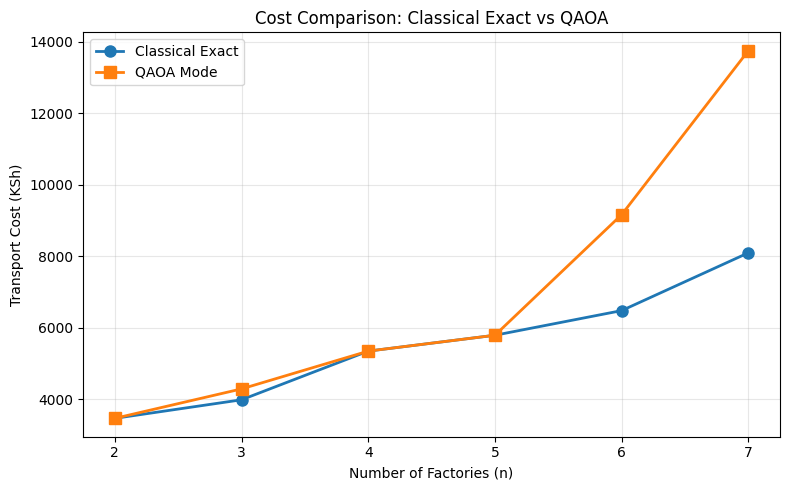

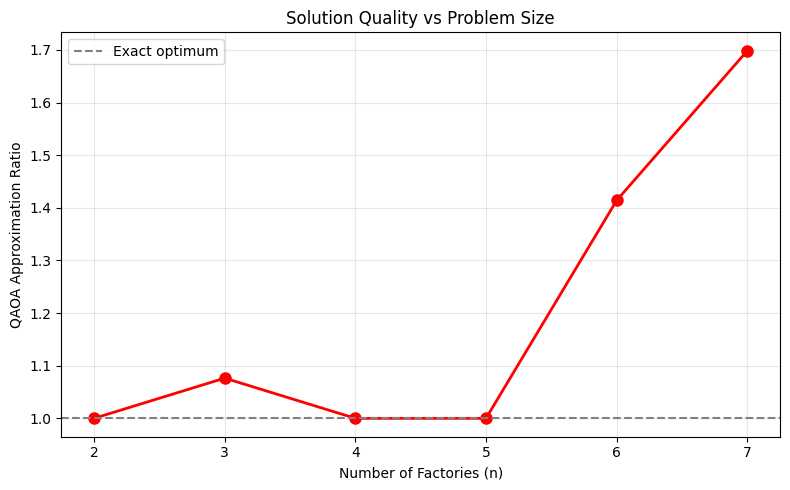

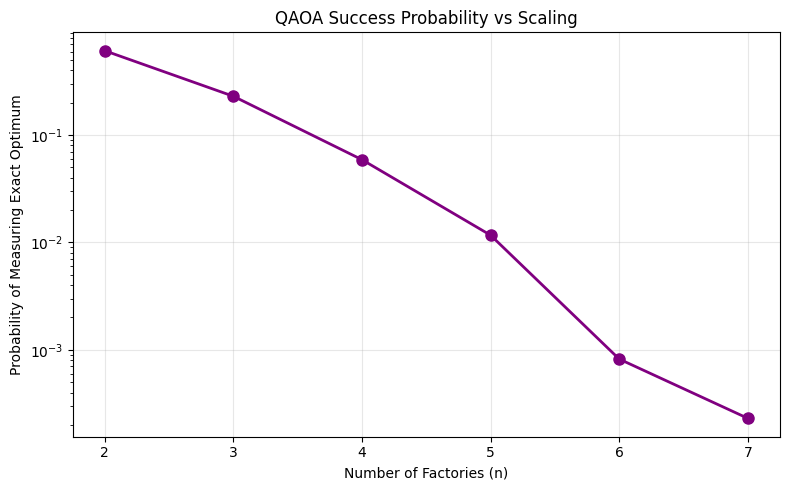

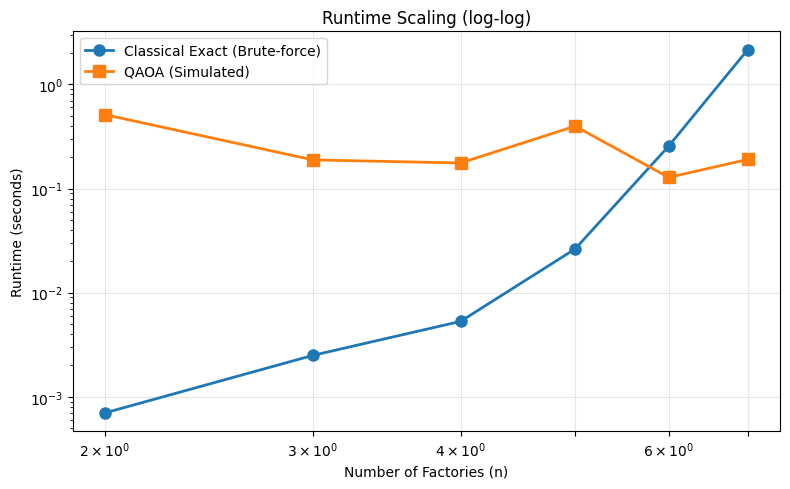

Plots saved as PNG files in the current directory.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# YOUR DATA (from the QAOA notebook)
# ============================================================
n = np.array([2, 3, 4, 5, 6, 7])

exact_cost   = np.array([3464.34, 3983.05, 5344.22, 5787.75, 6476.69, 8091.94])
qaoa_cost    = np.array([3464.34, 4287.35, 5344.22, 5787.75, 9158.37, 13743.62])
approx_ratio = qaoa_cost / exact_cost

optimal_prob = np.array([0.6107, 0.22996, 0.05899, 0.01168, 0.00082, 0.00023])
feasible_prob = np.array([1.0, 0.9730, 0.9991, 0.9994, 0.9664, 0.9565])

qaoa_runtime = np.array([0.5126, 0.1883, 0.1759, 0.3970, 0.1279, 0.1903])
classical_runtime = np.array([0.0007, 0.0025, 0.0053, 0.0263, 0.2557, 2.1619])

# ============================================================
# PLOT 1: Costs
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(n, exact_cost, 'o-', label='Classical Exact', linewidth=2, markersize=8)
plt.plot(n, qaoa_cost, 's-', label='QAOA Mode', linewidth=2, markersize=8)
plt.xlabel('Number of Factories (n)')
plt.ylabel('Transport Cost (KSh)')
plt.title('Cost Comparison: Classical Exact vs QAOA')
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('cost_comparison.png', dpi=300)
plt.show()

# ============================================================
# PLOT 2: Approximation Ratio
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(n, approx_ratio, 'o-', color='red', linewidth=2, markersize=8)
plt.axhline(y=1.0, color='gray', linestyle='--', label='Exact optimum')
plt.xlabel('Number of Factories (n)')
plt.ylabel('QAOA Approximation Ratio')
plt.title('Solution Quality vs Problem Size')
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('approx_ratio.png', dpi=300)
plt.show()

# ============================================================
# PLOT 3: Optimal Probability (log scale)
# ============================================================
plt.figure(figsize=(8,5))
plt.semilogy(n, optimal_prob, 'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Number of Factories (n)')
plt.ylabel('Probability of Measuring Exact Optimum')
plt.title('QAOA Success Probability vs Scaling')
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optimal_prob.png', dpi=300)
plt.show()

# ============================================================
# PLOT 4: Runtime Scaling (log scale)
# ============================================================
plt.figure(figsize=(8,5))
plt.loglog(n, classical_runtime, 'o-', label='Classical Exact (Brute-force)', linewidth=2, markersize=8)
plt.loglog(n, qaoa_runtime, 's-', label='QAOA (Simulated)', linewidth=2, markersize=8)
plt.xlabel('Number of Factories (n)')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime Scaling (log-log)')
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('runtime_scaling.png', dpi=300)
plt.show()

print("Plots saved as PNG files in the current directory.")

**CLASSICAL MILP SDVRP — SCALING EXPERIMENT**

This experiment evaluates how the classical mixed-integer linear programming (MILP) routing model scales as the number of factories increases from 2 to 7.

For each problem size, a complete single-depot, multi-truck split-delivery routing problem is solved from the Karatina depot. The model simultaneously optimizes truck routes, factory visit sequences, delivery quantities, and fertilizer load carried on each road segment.

The model minimizes fertilizer tonne-kilometre transport cost while satisfying truck capacity, factory demand, depot stock, and the 8-hour route-time limit.

Small instances are solved more tightly, while larger instances are evaluated using a fixed computational budget and MIP gap target. The results are used to measure how cost, routing structure, and computation time change as the number of factories increases.

In [ ]:

import math
import time
import pulp
import pandas as pd


# ============================================================
# 1. MODEL PARAMETERS
# ============================================================

# A genuine visit must represent at least 100 kg.
MIN_DELIVERY = 0.10

# Numerical tolerance only.
TOL = 1e-5


# ============================================================
# 2. BUILD THE FINAL MILP
# ============================================================

def build_final_model(factory_list):

    factories = list(factory_list)
    nodes = [DEPOT] + factories

    total_demand = sum(
        DEMAND[f] for f in factories
    )

    # Minimum number of 10-tonne truck trips required.
    num_trucks = math.ceil(
        total_demand / TRUCK_CAPACITY
    )

    model = pulp.LpProblem(
        "Final_Classical_SDVRP",
        pulp.LpMinimize
    )

    trucks = range(num_trucks)

    # --------------------------------------------------------
    # DECISION VARIABLES
    # --------------------------------------------------------

    # x[v,i,j] = 1 if truck v travels i -> j
    x = {}

    for v in trucks:
        for i in nodes:
            for j in nodes:

                if i != j:

                    x[v, i, j] = pulp.LpVariable(
                        f"x_{v}_{i}_{j}",
                        cat="Binary"
                    )

    # used[v] = 1 if truck v is used
    used = {
        v: pulp.LpVariable(
            f"used_{v}",
            cat="Binary"
        )
        for v in trucks
    }

    # visit[v,i] = 1 if truck v serves factory i
    visit = {}

    for v in trucks:
        for i in factories:

            visit[v, i] = pulp.LpVariable(
                f"visit_{v}_{i}",
                cat="Binary"
            )

    # q[v,i] = tonnes delivered by truck v to factory i
    q = {}

    for v in trucks:
        for i in factories:

            q[v, i] = pulp.LpVariable(
                f"q_{v}_{i}",
                lowBound=0,
                upBound=TRUCK_CAPACITY,
                cat="Continuous"
            )

    # load[v,i,j] = tonnes carried on arc i -> j
    load = {}

    for v in trucks:
        for i in nodes:
            for j in nodes:

                if i != j:

                    load[v, i, j] = pulp.LpVariable(
                        f"load_{v}_{i}_{j}",
                        lowBound=0,
                        upBound=TRUCK_CAPACITY,
                        cat="Continuous"
                    )

    # MTZ order
    order = {}

    for v in trucks:
        for i in factories:

            order[v, i] = pulp.LpVariable(
                f"order_{v}_{i}",
                lowBound=0,
                upBound=len(factories),
                cat="Continuous"
            )

    # ========================================================
    # OBJECTIVE
    # ========================================================
    #
    # Cost = 16 KSh/t-km × actual load carried × road distance
    #
    # Empty return has zero fertilizer transport cost.
    #
    # ========================================================

    model += pulp.lpSum(
        RATE
        * DISTANCE[(i, j)]
        * load[v, i, j]

        for v in trucks
        for i in nodes
        for j in nodes

        if i != j
    ), "Total_TonneKm_Cost"

    # ========================================================
    # 3. DEMAND
    # ========================================================

    for i in factories:

        model += (
            pulp.lpSum(
                q[v, i]
                for v in trucks
            )
            ==
            DEMAND[i]
        ), f"Demand_{i}"

    # ========================================================
    # 4. DEPOT STOCK
    # ========================================================

    model += (
        pulp.lpSum(
            q[v, i]
            for v in trucks
            for i in factories
        )
        <=
        DEPOT_STOCK
    ), "DepotStock"

    # ========================================================
    # 5. TRUCK CAPACITY
    # ========================================================

    for v in trucks:

        model += (
            pulp.lpSum(
                q[v, i]
                for i in factories
            )
            <=
            TRUCK_CAPACITY * used[v]
        ), f"Capacity_{v}"

    # ========================================================
    # 6. DEPOT DEPARTURE / RETURN
    # ========================================================

    for v in trucks:

        model += (
            pulp.lpSum(
                x[v, DEPOT, j]
                for j in factories
            )
            ==
            used[v]
        ), f"DepartDepot_{v}"

        model += (
            pulp.lpSum(
                x[v, i, DEPOT]
                for i in factories
            )
            ==
            used[v]
        ), f"ReturnDepot_{v}"

    # ========================================================
    # 7. FACTORY FLOW
    # ========================================================

    for v in trucks:

        for i in factories:

            # One arrival if visited
            model += (
                pulp.lpSum(
                    x[v, j, i]
                    for j in nodes
                    if j != i
                )
                ==
                visit[v, i]
            ), f"Arrival_{v}_{i}"

            # One departure if visited
            model += (
                pulp.lpSum(
                    x[v, i, j]
                    for j in nodes
                    if j != i
                )
                ==
                visit[v, i]
            ), f"Departure_{v}_{i}"

            # Meaningful delivery if visited
            model += (
                q[v, i]
                >=
                MIN_DELIVERY * visit[v, i]
            ), f"MinimumDelivery_{v}_{i}"

            # Delivery cannot exceed truck capacity
            model += (
                q[v, i]
                <=
                TRUCK_CAPACITY * visit[v, i]
            ), f"DeliveryCapacity_{v}_{i}"

            # Visited factory requires used truck
            model += (
                visit[v, i]
                <=
                used[v]
            ), f"VisitRequiresTruck_{v}_{i}"

    # ========================================================
    # 8. LOAD ONLY ON USED ARCS
    # ========================================================

    for v in trucks:

        for i in nodes:

            for j in nodes:

                if i != j:

                    model += (
                        load[v, i, j]
                        <=
                        TRUCK_CAPACITY * x[v, i, j]
                    ), f"ArcLoad_{v}_{i}_{j}"

    # ========================================================
    # 9. LOAD CONSERVATION
    #
    # incoming load - outgoing load = delivery
    # ========================================================

    for v in trucks:

        for i in factories:

            incoming = pulp.lpSum(
                load[v, j, i]
                for j in nodes
                if j != i
            )

            outgoing = pulp.lpSum(
                load[v, i, j]
                for j in nodes
                if j != i
            )

            model += (
                incoming
                -
                outgoing
                ==
                q[v, i]
            ), f"LoadBalance_{v}_{i}"

    # ========================================================
    # 10. LOAD LEAVING DEPOT
    # ========================================================

    for v in trucks:

        model += (
            pulp.lpSum(
                load[v, DEPOT, j]
                for j in factories
            )
            ==
            pulp.lpSum(
                q[v, i]
                for i in factories
            )
        ), f"DepotLoad_{v}"

    # ========================================================
    # 11. EMPTY RETURN
    # ========================================================

    for v in trucks:

        for i in factories:

            model += (
                load[v, i, DEPOT]
                ==
                0
            ), f"EmptyReturn_{v}_{i}"

    # ========================================================
    # 12. MAXIMUM ROUTE TIME
    # ========================================================

    for v in trucks:

        model += (
            pulp.lpSum(
                TRAVEL_TIME[(i, j)]
                * x[v, i, j]

                for i in nodes
                for j in nodes

                if i != j
            )
            <=
            MAX_ROUTE_TIME * used[v]
        ), f"RouteTime_{v}"

    # ========================================================
    # 13. MTZ SUBTOUR ELIMINATION
    # ========================================================

    n = len(factories)

    for v in trucks:

        for i in factories:

            model += (
                order[v, i]
                <=
                n * visit[v, i]
            ), f"MTZUpper_{v}_{i}"

            model += (
                order[v, i]
                >=
                visit[v, i]
            ), f"MTZLower_{v}_{i}"

        for i in factories:
            for j in factories:

                if i != j:

                    model += (
                        order[v, i]
                        -
                        order[v, j]
                        +
                        n * x[v, i, j]
                        <=
                        n - 1
                    ), f"MTZ_{v}_{i}_{j}"

    # ========================================================
    # 14. TRUCK SYMMETRY BREAKING
    #
    # Trucks are identical.
    #
    # Force:
    # used[0] >= used[1] >= used[2] ...
    #
    # This prevents CBC from wasting time finding equivalent
    # solutions that differ only in truck numbering.
    # ========================================================

    for v in range(num_trucks - 1):

        model += (
            used[v]
            >=
            used[v + 1]
        ), f"TruckSymmetry_{v}"

    return (
        model,
        x,
        used,
        q,
        load,
        visit,
        order,
        trucks,
        nodes
    )


# ============================================================
# 3. EXTRACT SOLUTION
# ============================================================

def extract_final_solution(
    model,
    x,
    used,
    q,
    load,
    trucks,
    factories
):

    nodes = [DEPOT] + list(factories)

    routes = []

    for v in trucks:

        used_value = pulp.value(
            used[v]
        )

        if used_value is None or used_value < 0.5:
            continue

        route = [DEPOT]
        current = DEPOT
        seen = set()

        while True:

            next_node = None

            for j in nodes:

                if j == current:
                    continue

                variable = x.get(
                    (v, current, j)
                )

                if variable is None:
                    continue

                value = pulp.value(
                    variable
                )

                if value is not None and value > 0.5:

                    next_node = j
                    break

            if next_node is None:
                break

            route.append(next_node)

            if next_node == DEPOT:
                break

            if next_node in seen:

                raise RuntimeError(
                    f"Route cycle detected for truck {v+1}"
                )

            seen.add(next_node)
            current = next_node

        deliveries = {}

        for f in factories:

            amount = pulp.value(
                q[v, f]
            )

            if amount is None:
                amount = 0.0

            if amount > TOL:

                deliveries[f] = amount

        if not deliveries:
            continue

        total_distance = 0.0
        total_time = 0.0
        total_tonne_km = 0.0
        total_cost = 0.0

        arc_details = []

        for k in range(
            len(route) - 1
        ):

            i = route[k]
            j = route[k + 1]

            distance = DISTANCE[
                (i, j)
            ]

            travel_time = TRAVEL_TIME[
                (i, j)
            ]

            segment_load = pulp.value(
                load[v, i, j]
            )

            if segment_load is None:
                segment_load = 0.0

            segment_tonne_km = (
                segment_load
                *
                distance
            )

            segment_cost = (
                RATE
                *
                segment_tonne_km
            )

            total_distance += distance
            total_time += travel_time
            total_tonne_km += segment_tonne_km
            total_cost += segment_cost

            arc_details.append({

                "from": i,

                "to": j,

                "load_tonnes":
                    segment_load,

                "distance_km":
                    distance,

                "time_hours":
                    travel_time,

                "tonne_km":
                    segment_tonne_km,

                "cost_ksh":
                    segment_cost
            })

        number_of_factories = sum(
            1
            for node in route
            if node != DEPOT
        )

        routes.append({

            "truck":
                v + 1,

            "route_list":
                route,

            "route":
                " -> ".join(route),

            "deliveries":
                deliveries,

            "delivered_tonnes":
                sum(deliveries.values()),

            "distance_km":
                total_distance,

            "time_hours":
                total_time,

            "tonne_km":
                total_tonne_km,

            "cost_ksh":
                total_cost,

            "number_of_factories":
                number_of_factories,

            "multi_stop":
                number_of_factories >= 2,

            "arcs":
                arc_details
        })

    return {

        "routes":
            routes,

        "cost":
            sum(
                r["cost_ksh"]
                for r in routes
            ),

        "distance":
            sum(
                r["distance_km"]
                for r in routes
            ),

        "tonne_km":
            sum(
                r["tonne_km"]
                for r in routes
            ),

        "delivered":
            sum(
                r["delivered_tonnes"]
                for r in routes
            ),

        "trucks":
            len(routes),

        "multi_stop_routes":
            sum(
                1
                for r in routes
                if r["multi_stop"]
            )
    }


# ============================================================
# 4. VALIDATION
# ============================================================

def validate_final_solution(
    solution,
    factories
):

    tolerance = 1e-4

    # --------------------------------------------------------
    # Demand
    # --------------------------------------------------------

    delivered_by_factory = {
        f: 0.0
        for f in factories
    }

    for route in solution["routes"]:

        for factory, amount in \
                route["deliveries"].items():

            delivered_by_factory[
                factory
            ] += amount

    for factory in factories:

        demand = DEMAND[factory]
        delivered = delivered_by_factory[
            factory
        ]

        if abs(
            demand - delivered
        ) > tolerance:

            raise ValueError(
                f"Demand violation: "
                f"{factory} "
                f"demand={demand} "
                f"delivered={delivered}"
            )

    # --------------------------------------------------------
    # Truck capacity and time
    # --------------------------------------------------------

    for route in solution["routes"]:

        if (
            route["delivered_tonnes"]
            >
            TRUCK_CAPACITY + tolerance
        ):

            raise ValueError(
                f"Capacity violation "
                f"truck {route['truck']}"
            )

        if (
            route["time_hours"]
            >
            MAX_ROUTE_TIME + tolerance
        ):

            raise ValueError(
                f"Route time violation "
                f"truck {route['truck']}"
            )

        if route["route_list"][0] != DEPOT:

            raise ValueError(
                "Route does not start at depot."
            )

        if route["route_list"][-1] != DEPOT:

            raise ValueError(
                "Route does not return to depot."
            )

    # --------------------------------------------------------
    # Stock
    # --------------------------------------------------------

    if (
        solution["delivered"]
        >
        DEPOT_STOCK + tolerance
    ):

        raise ValueError(
            "Depot stock constraint violated."
        )

    # --------------------------------------------------------
    # Cost consistency
    # --------------------------------------------------------

    independent_cost = (
        RATE * solution["tonne_km"]
    )

    if abs(
        independent_cost
        -
        solution["cost"]
    ) > 1e-3:

        raise ValueError(
            "Cost consistency check failed."
        )

    return True


# ============================================================
# 5. SOLVE ONE INSTANCE
# ============================================================

def solve_final_instance(
    factory_list,
    time_limit=300,
    gap_rel=0.01
):

    factories = list(factory_list)

    total_demand = sum(
        DEMAND[f]
        for f in factories
    )

    minimum_trips = math.ceil(
        total_demand / TRUCK_CAPACITY
    )

    print("\n" + "=" * 100)
    print(
        f"FACTORIES: {len(factories)}"
    )
    print(
        f"Customers: {factories}"
    )
    print(
        f"Demand: {total_demand:.3f} t"
    )
    print(
        f"Minimum trips: {minimum_trips}"
    )
    print(
        f"Time limit: {time_limit} s"
    )
    print(
        f"MIP gap target: {gap_rel*100:.2f}%"
    )
    print("=" * 100)

    (
        model,
        x,
        used,
        q,
        load,
        visit,
        order,
        trucks,
        nodes
    ) = build_final_model(
        factories
    )

    start = time.perf_counter()

    solver = pulp.PULP_CBC_CMD(
        msg=False,
        timeLimit=time_limit,
        gapRel=gap_rel
    )

    model.solve(
        solver
    )

    runtime = (
        time.perf_counter()
        -
        start
    )

    status = pulp.LpStatus[
        model.status
    ]

    objective_value = pulp.value(
        model.objective
    )

    print(
        f"Solver status: {status}"
    )

    print(
        f"Runtime: {runtime:.2f} s"
    )

    if objective_value is None:

        print(
            "No feasible solution found."
        )

        return None

    solution = extract_final_solution(
        model,
        x,
        used,
        q,
        load,
        trucks,
        factories
    )

    validate_final_solution(
        solution,
        factories
    )

    # --------------------------------------------------------
    # Correct quality label
    # --------------------------------------------------------

    if (
        status == "Optimal"
        and
        gap_rel == 0
        and
        runtime < time_limit - 1.0
    ):

        quality = "PROVEN OPTIMAL"

    elif status == "Optimal" and gap_rel == 0:

        quality = "CBC OPTIMAL"

    else:

        quality = (
            "BEST FEASIBLE FOUND "
            "WITHIN COMPUTATIONAL BUDGET"
        )

    solution["status"] = status
    solution["quality"] = quality
    solution["runtime"] = runtime
    solution["solver_objective"] = objective_value
    solution["factory_count"] = len(factories)

    print(
        f"Quality: {quality}"
    )

    print(
        f"Cost: KSh {solution['cost']:,.2f}"
    )

    print(
        f"Distance: {solution['distance']:,.2f} km"
    )

    print(
        f"Tonne-km: {solution['tonne_km']:,.2f}"
    )

    print(
        f"Delivered: {solution['delivered']:,.3f} t"
    )

    print(
        f"Trips: {solution['trucks']}"
    )

    print(
        f"Multi-stop: "
        f"{solution['multi_stop_routes']}"
    )

    return solution


# ============================================================
# 6. PRINT ROUTES
# ============================================================

def print_routes(solution):

    print("\n" + "=" * 100)
    print("ROUTE DETAILS")
    print("=" * 100)

    for route in solution["routes"]:

        print(
            f"\nTruck {route['truck']}: "
            f"{route['route']}"
        )

        print(
            f"  Delivered: "
            f"{route['delivered_tonnes']:.3f} t"
        )

        print(
            f"  Distance: "
            f"{route['distance_km']:.2f} km"
        )

        print(
            f"  Time: "
            f"{route['time_hours']:.2f} h"
        )

        print(
            f"  Cost: "
            f"KSh {route['cost_ksh']:,.2f}"
        )

        print("  Deliveries:")

        for factory, amount in \
                route["deliveries"].items():

            print(
                f"    {factory:12s}: "
                f"{amount:.3f} t"
            )

        print("  Arc loads:")

        for arc in route["arcs"]:

            print(
                f"    {arc['from']} -> "
                f"{arc['to']} | "
                f"load={arc['load_tonnes']:.3f} t | "
                f"distance={arc['distance_km']:.2f} km | "
                f"cost=KSh {arc['cost_ksh']:,.2f}"
            )


# ============================================================
# 7. RUN 2 -> 7 SCALING
# ============================================================
#
# Small:
#   exact solve
#
# Larger:
#   fixed 300-second budget + 1% gap target
#
# ============================================================

def run_final_scaling():

    rows = []
    solutions = {}

    for n in range(2, 8):

        factories = FACTORIES_ALL[:n]

        if n <= 3:

            time_limit = 600
            gap_rel = 0.0

        else:

            time_limit = 300
            gap_rel = 0.01

        solution = solve_final_instance(
            factories,
            time_limit=time_limit,
            gap_rel=gap_rel
        )

        if solution is None:

            rows.append({

                "Factories":
                    n,

                "Factory_Set":
                    " | ".join(factories),

                "Status":
                    "No feasible solution",

                "Solution_Quality":
                    "None",

                "Cost_KSh":
                    None,

                "Distance_km":
                    None,

                "Tonne_km":
                    None,

                "Delivered_tonnes":
                    None,

                "Trips":
                    None,

                "Multi_Stop_Trips":
                    None,

                "Runtime_s":
                    None
            })

            continue

        solutions[n] = solution

        rows.append({

            "Factories":
                n,

            "Factory_Set":
                " | ".join(factories),

            "Status":
                solution["status"],

            "Solution_Quality":
                solution["quality"],

            "Cost_KSh":
                solution["cost"],

            "Distance_km":
                solution["distance"],

            "Tonne_km":
                solution["tonne_km"],

            "Delivered_tonnes":
                solution["delivered"],

            "Trips":
                solution["trucks"],

            "Multi_Stop_Trips":
                solution["multi_stop_routes"],

            "Runtime_s":
                solution["runtime"]
        })

    df = pd.DataFrame(rows)

    return df, solutions


# ============================================================
# 8. RUN THE FINAL EXPERIMENT
# ============================================================

scaling_df, scaling_solutions = \
    run_final_scaling()


# ============================================================
# 9. DISPLAY FINAL SCALING TABLE
# ============================================================

print("\n")
print("=" * 120)
print("FINAL CLASSICAL MILP SDVRP SCALING RESULTS")
print("=" * 120)

print(
    scaling_df.to_string(
        index=False,
        formatters={

            "Cost_KSh":
                lambda x:
                ""
                if pd.isna(x)
                else f"{x:,.2f}",

            "Distance_km":
                lambda x:
                ""
                if pd.isna(x)
                else f"{x:,.2f}",

            "Tonne_km":
                lambda x:
                ""
                if pd.isna(x)
                else f"{x:,.2f}",

            "Delivered_tonnes":
                lambda x:
                ""
                if pd.isna(x)
                else f"{x:,.3f}",

            "Runtime_s":
                lambda x:
                ""
                if pd.isna(x)
                else f"{x:.2f}"
        }
    )
)

# Save results
scaling_df.to_excel(
    "FINAL_Classical_SDVRP_Scaling_2_to_7.xlsx",
    index=False
)

print(
    "\nSaved:"
    " FINAL_Classical_SDVRP_Scaling_2_to_7.xlsx"
)


# ============================================================
# 10. PRINT ONLY THE 7-FACTORY SOLUTION
# ============================================================

if 7 in scaling_solutions:

    print("\n")
    print("#" * 100)
    print("# FINAL 7-FACTORY CLASSICAL SOLUTION")
    print("#" * 100)

    final_7 = scaling_solutions[7]

    print(
        f"Quality: "
        f"{final_7['quality']}"
    )

    print(
        f"Cost: "
        f"KSh {final_7['cost']:,.2f}"
    )

    print(
        f"Distance: "
        f"{final_7['distance']:,.2f} km"
    )

    print(
        f"Tonne-km: "
        f"{final_7['tonne_km']:,.2f}"
    )

    print(
        f"Delivered: "
        f"{final_7['delivered']:,.3f} t"
    )

    print(
        f"Trips: "
        f"{final_7['trucks']}"
    )

    print(
        f"Multi-stop routes: "
        f"{final_7['multi_stop_routes']}"
    )

    print(
        f"Runtime: "
        f"{final_7['runtime']:.2f} s"
    )

    print_routes(
        final_7
    )


FACTORIES: 2
Customers: ['Mukangu', 'Ragati']
Demand: 51.579 t
Minimum trips: 6
Time limit: 600 s
MIP gap target: 0.00%
Solver status: Optimal
Runtime: 0.05 s
Quality: PROVEN OPTIMAL
Cost: KSh 9,108.76
Distance: 131.40 km
Tonne-km: 569.30
Delivered: 51.579 t
Trips: 6
Multi-stop: 0

FACTORIES: 3
Customers: ['Mukangu', 'Ragati', 'Chema']
Demand: 62.427 t
Minimum trips: 7
Time limit: 600 s
MIP gap target: 0.00%
Solver status: Optimal
Runtime: 131.74 s
Quality: PROVEN OPTIMAL
Cost: KSh 11,337.57
Distance: 166.96 km
Tonne-km: 708.60
Delivered: 62.427 t
Trips: 7
Multi-stop: 1

FACTORIES: 4
Customers: ['Mukangu', 'Ragati', 'Chema', 'Kianjega']
Demand: 86.949 t
Minimum trips: 9
Time limit: 300 s
MIP gap target: 1.00%
Solver status: Optimal
Runtime: 300.47 s
Quality: BEST FEASIBLE FOUND WITHIN COMPUTATIONAL BUDGET
Cost: KSh 17,329.27
Distance: 237.18 km
Tonne-km: 1,083.08
Delivered: 86.949 t
Trips: 9
Multi-stop: 2

FACTORIES: 5
Customers: ['Mukangu', 'Ragati', 'Chema', 'Kianjega', 'Nguguini']


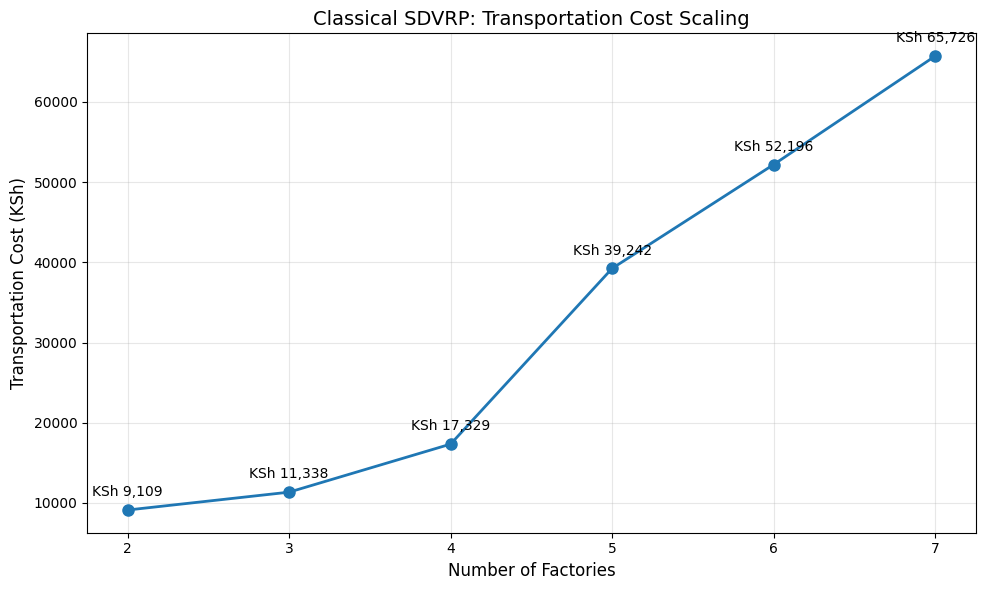

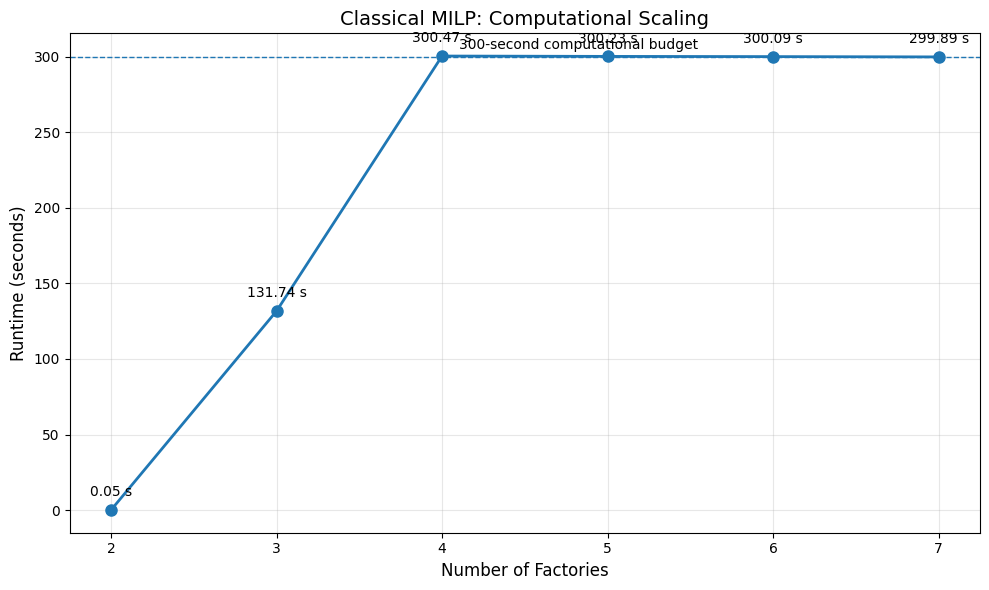

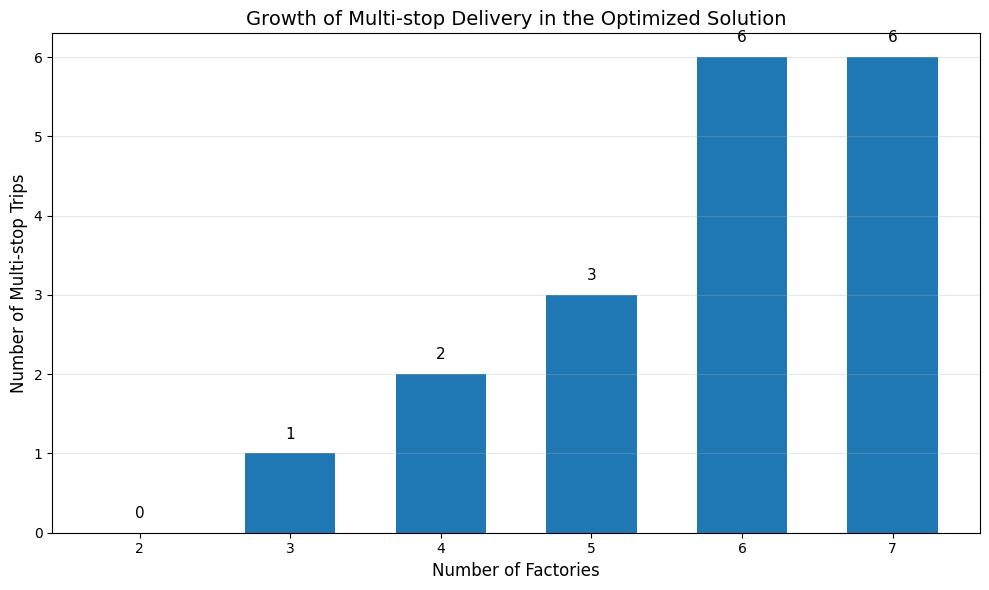

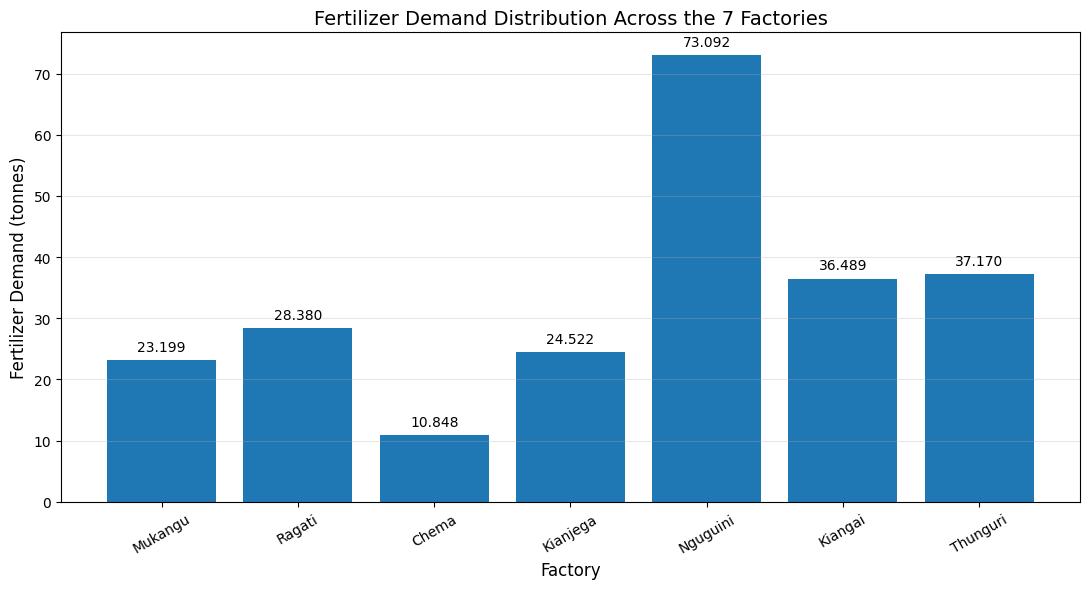

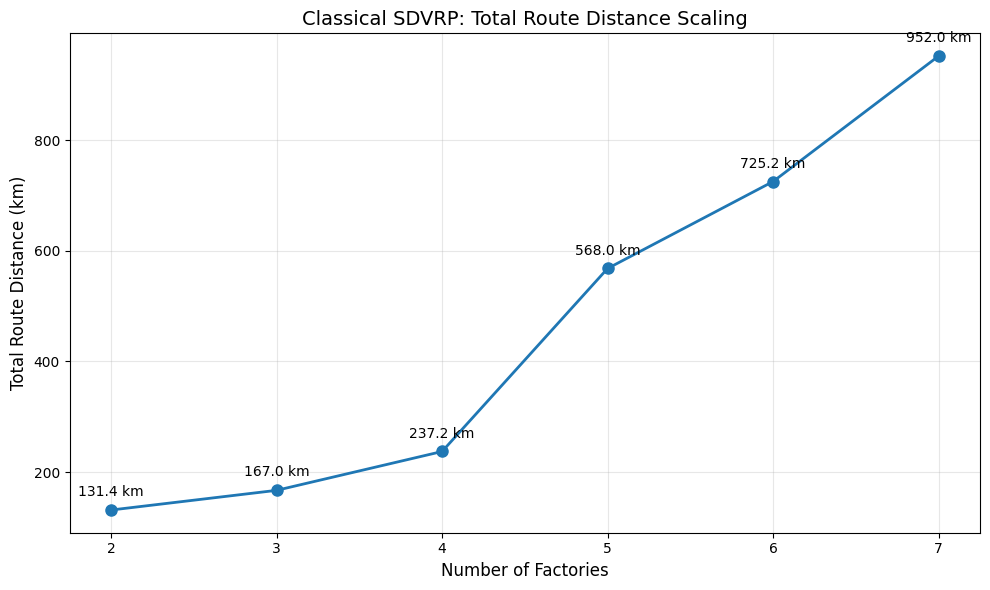


CLASSICAL SDVRP PRESENTATION RESULTS
2 factories | Demand=51.579 t | Cost=KSh 9,108.76 | Distance=131.40 km | Trips=6 | Multi-stop=0 | Runtime=0.05 s
3 factories | Demand=62.427 t | Cost=KSh 11,337.57 | Distance=166.96 km | Trips=7 | Multi-stop=1 | Runtime=131.74 s
4 factories | Demand=86.949 t | Cost=KSh 17,329.27 | Distance=237.18 km | Trips=9 | Multi-stop=2 | Runtime=300.47 s
5 factories | Demand=160.041 t | Cost=KSh 39,242.10 | Distance=567.97 km | Trips=17 | Multi-stop=3 | Runtime=300.23 s
6 factories | Demand=196.530 t | Cost=KSh 52,195.62 | Distance=725.16 km | Trips=20 | Multi-stop=6 | Runtime=300.09 s
7 factories | Demand=233.700 t | Cost=KSh 65,726.48 | Distance=951.95 km | Trips=24 | Multi-stop=6 | Runtime=299.89 s
Plots saved successfully.


In [ ]:
# ============================================================
# QSOLVE AGRICULTURE TRACK 1
# CLASSICAL SDVRP - PRESENTATION VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. CLASSICAL SCALING DATA
# ============================================================

factories = np.array([2, 3, 4, 5, 6, 7])

demand = np.array([
    51.579,
    62.427,
    86.949,
    160.041,
    196.530,
    233.700
])

cost = np.array([
    9108.76,
    11337.57,
    17329.27,
    39242.10,
    52195.62,
    65726.48
])

distance = np.array([
    131.40,
    166.96,
    237.18,
    567.97,
    725.16,
    951.95
])

tonne_km = np.array([
    569.30,
    708.60,
    1083.08,
    2452.63,
    3262.23,
    4107.90
])

trips = np.array([
    6,
    7,
    9,
    17,
    20,
    24
])

multi_stop = np.array([
    0,
    1,
    2,
    3,
    6,
    6
])

runtime = np.array([
    0.05,
    131.74,
    300.47,
    300.23,
    300.09,
    299.89
])


# ============================================================
# 2. FACTORY DEMAND DATA - 7 FACTORY CASE
# ============================================================

factory_names = [
    "Mukangu",
    "Ragati",
    "Chema",
    "Kianjega",
    "Nguguini",
    "Kiangai",
    "Thunguri"
]

factory_demand = np.array([
    23.199,
    28.380,
    10.848,
    24.522,
    73.092,
    36.489,
    37.170
])


# ============================================================
# 3. FIGURE 1
#    FACTORIES VS TRANSPORTATION COST
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    factories,
    cost,
    marker="o",
    linewidth=2,
    markersize=8
)

for x, y in zip(factories, cost):
    plt.annotate(
        f"KSh {y:,.0f}",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Number of Factories", fontsize=12)
plt.ylabel("Transportation Cost (KSh)", fontsize=12)

plt.title(
    "Classical SDVRP: Transportation Cost Scaling",
    fontsize=14
)

plt.xticks(factories)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "01_classical_cost_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 4. FIGURE 2
#    FACTORIES VS COMPUTATIONAL TIME
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    factories,
    runtime,
    marker="o",
    linewidth=2,
    markersize=8
)

for x, y in zip(factories, runtime):
    plt.annotate(
        f"{y:.2f} s",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Number of Factories", fontsize=12)
plt.ylabel("Runtime (seconds)", fontsize=12)

plt.title(
    "Classical MILP: Computational Scaling",
    fontsize=14
)

plt.xticks(factories)
plt.grid(True, alpha=0.3)

# Important annotation
plt.axhline(
    300,
    linestyle="--",
    linewidth=1
)

plt.text(
    4.1,
    305,
    "300-second computational budget"
)

plt.tight_layout()

plt.savefig(
    "02_classical_runtime_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 5. FIGURE 3
#    FACTORIES VS MULTI-STOP TRIPS
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    factories,
    multi_stop,
    width=0.6
)

for bar, value in zip(bars, multi_stop):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        str(value),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.xlabel("Number of Factories", fontsize=12)
plt.ylabel("Number of Multi-stop Trips", fontsize=12)

plt.title(
    "Growth of Multi-stop Delivery in the Optimized Solution",
    fontsize=14
)

plt.xticks(factories)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "03_multistop_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. FIGURE 4
#    FERTILIZER DEMAND BY FACTORY
# ============================================================

plt.figure(figsize=(11, 6))

bars = plt.bar(
    factory_names,
    factory_demand
)

for bar, value in zip(bars, factory_demand):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Factory", fontsize=12)
plt.ylabel("Fertilizer Demand (tonnes)", fontsize=12)

plt.title(
    "Fertilizer Demand Distribution Across the 7 Factories",
    fontsize=14
)

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "04_factory_demand.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FIGURE 5
#    TOTAL DISTANCE VS NUMBER OF FACTORIES
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    factories,
    distance,
    marker="o",
    linewidth=2,
    markersize=8
)

for x, y in zip(factories, distance):
    plt.annotate(
        f"{y:.1f} km",
        (x, y),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("Number of Factories", fontsize=12)
plt.ylabel("Total Route Distance (km)", fontsize=12)

plt.title(
    "Classical SDVRP: Total Route Distance Scaling",
    fontsize=14
)

plt.xticks(factories)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "05_distance_scaling.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. PRINT SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CLASSICAL SDVRP PRESENTATION RESULTS")
print("=" * 70)

for i in range(len(factories)):
    print(
        f"{factories[i]} factories | "
        f"Demand={demand[i]:.3f} t | "
        f"Cost=KSh {cost[i]:,.2f} | "
        f"Distance={distance[i]:.2f} km | "
        f"Trips={trips[i]} | "
        f"Multi-stop={multi_stop[i]} | "
        f"Runtime={runtime[i]:.2f} s"
    )

print("=" * 70)
print("Plots saved successfully.")

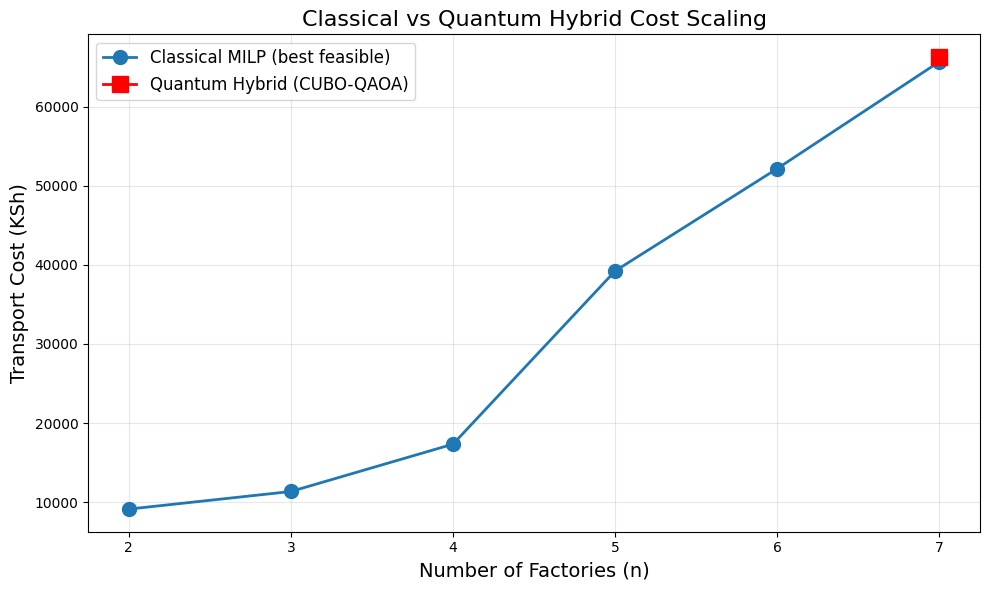

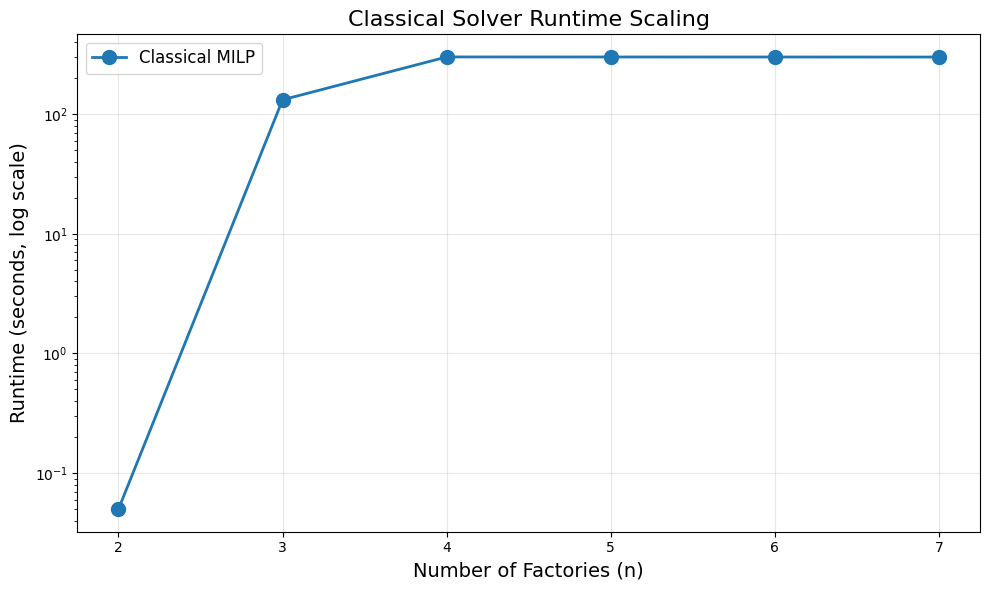

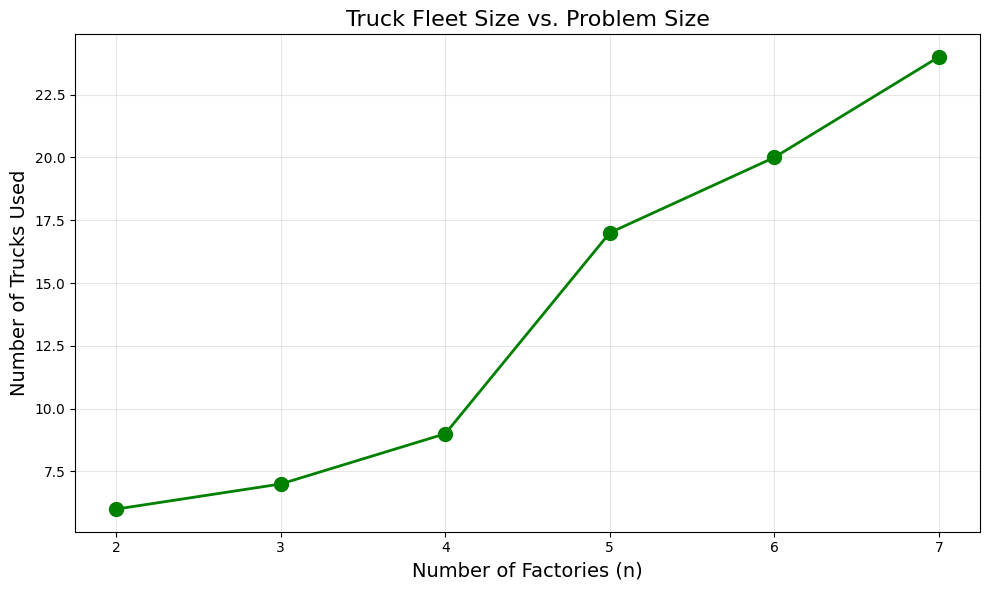

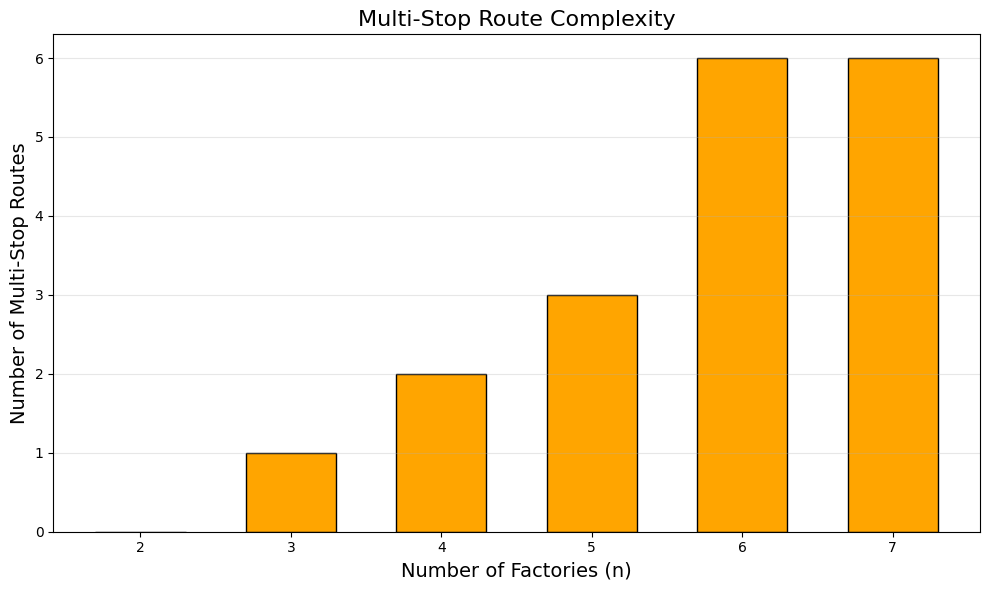

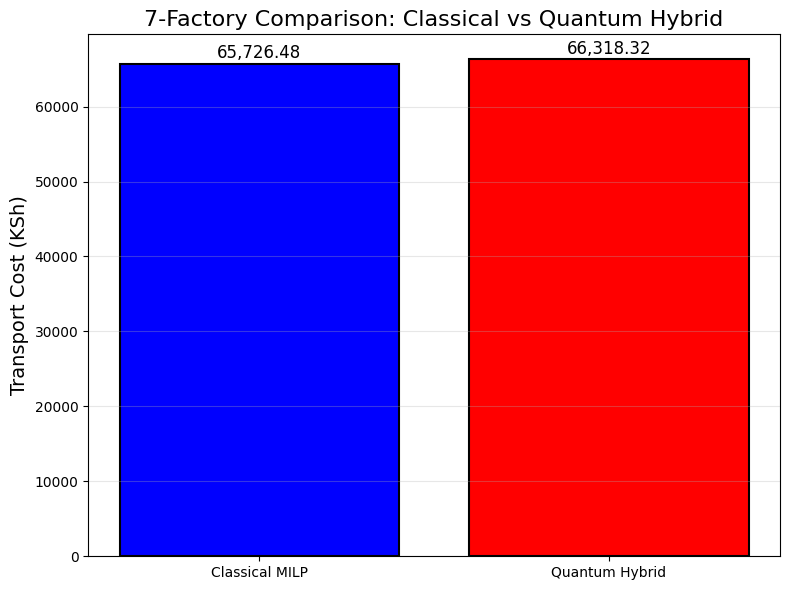

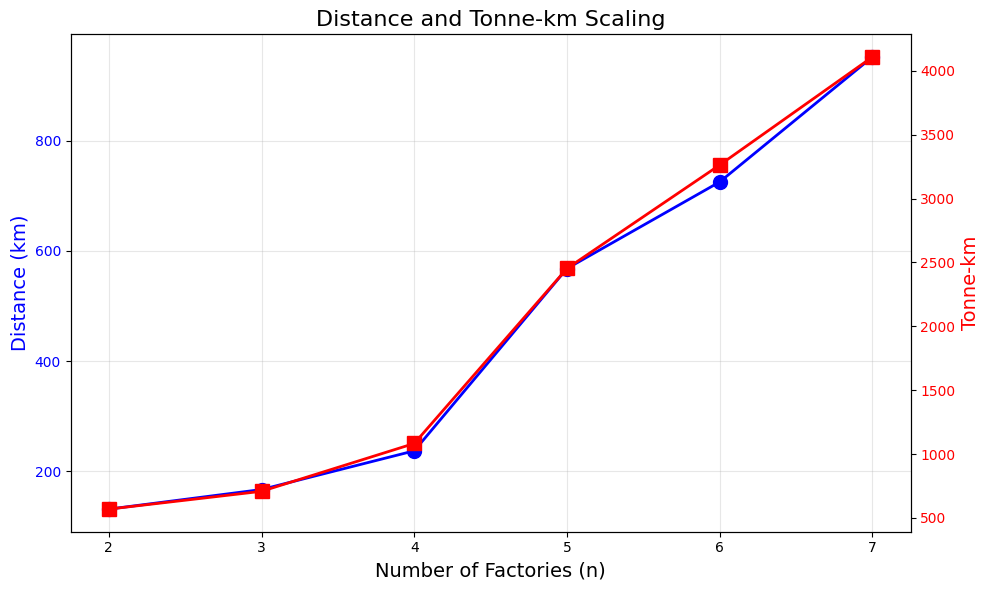


CLASSICAL SCALING RESULTS
 n Cost (KSh) Distance (km) Tonne-km  Trucks  Multi-Stop Runtime (s)
 2   9,108.76        131.40   569.30       6           0        0.05
 3  11,337.57        166.96   708.60       7           1      131.74
 4  17,329.27        237.18  1083.08       9           2      300.47
 5  39,242.10        567.97  2452.63      17           3      300.23
 6  52,195.62        725.16  3262.23      20           6      300.09
 7  65,726.48        951.95  4107.90      24           6      299.89

7-FACTORY QUANTUM HYBRID COST: KSh 66318.32
GAP vs CLASSICAL: 0.90%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# DATA
# ============================================================

n = np.array([2, 3, 4, 5, 6, 7])

# Classical MILP results (from your scaling run)
classical_cost = np.array([9108.76, 11337.57, 17329.27, 39242.10, 52195.62, 65726.48])
classical_runtime = np.array([0.05, 131.74, 300.47, 300.23, 300.09, 299.89])
classical_trucks = np.array([6, 7, 9, 17, 20, 24])
classical_multistop = np.array([0, 1, 2, 3, 6, 6])
classical_distance = np.array([131.40, 166.96, 237.18, 567.97, 725.16, 951.95])
classical_tonne_km = np.array([569.30, 708.60, 1083.08, 2452.63, 3262.23, 4107.90])

# Quantum hybrid result (only 7 factories)
q_cost_7 = 66318.32
q_n = 7

# ============================================================
# PLOT 1: COST SCALING
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(n, classical_cost, 'o-', linewidth=2, markersize=10, label='Classical MILP (best feasible)')
plt.plot(q_n, q_cost_7, 's-', color='red', linewidth=2, markersize=12, label='Quantum Hybrid (CUBO-QAOA)')
plt.xlabel('Number of Factories (n)', fontsize=14)
plt.ylabel('Transport Cost (KSh)', fontsize=14)
plt.title('Classical vs Quantum Hybrid Cost Scaling', fontsize=16)
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('Cost_Scaling.png', dpi=300)
plt.show()

# ============================================================
# PLOT 2: RUNTIME SCALING (LOG SCALE)
# ============================================================
plt.figure(figsize=(10, 6))
plt.semilogy(n, classical_runtime, 'o-', linewidth=2, markersize=10, label='Classical MILP')
plt.xlabel('Number of Factories (n)', fontsize=14)
plt.ylabel('Runtime (seconds, log scale)', fontsize=14)
plt.title('Classical Solver Runtime Scaling', fontsize=16)
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('Runtime_Scaling.png', dpi=300)
plt.show()

# ============================================================
# PLOT 3: TRUCKS USED
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(n, classical_trucks, 'o-', linewidth=2, markersize=10, color='green')
plt.xlabel('Number of Factories (n)', fontsize=14)
plt.ylabel('Number of Trucks Used', fontsize=14)
plt.title('Truck Fleet Size vs. Problem Size', fontsize=16)
plt.xticks(n)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Trucks_Used.png', dpi=300)
plt.show()

# ============================================================
# PLOT 4: MULTI-STOP ROUTES
# ============================================================
plt.figure(figsize=(10, 6))
plt.bar(n, classical_multistop, width=0.6, color='orange', edgecolor='black')
plt.xlabel('Number of Factories (n)', fontsize=14)
plt.ylabel('Number of Multi-Stop Routes', fontsize=14)
plt.title('Multi-Stop Route Complexity', fontsize=16)
plt.xticks(n)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('MultiStop_Routes.png', dpi=300)
plt.show()

# ============================================================
# PLOT 5: 7-FACTORY COMPARISON (BAR CHART)
# ============================================================
plt.figure(figsize=(8, 6))
bars = plt.bar(['Classical MILP', 'Quantum Hybrid'], [classical_cost[-1], q_cost_7],
               color=['blue', 'red'], edgecolor='black', linewidth=1.5)
plt.ylabel('Transport Cost (KSh)', fontsize=14)
plt.title('7-Factory Comparison: Classical vs Quantum Hybrid', fontsize=16)
plt.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 200,
             f'{height:,.2f}', ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.savefig('7Factory_Comparison.png', dpi=300)
plt.show()

# ============================================================
# PLOT 6: DISTANCE & TONNE-KM (secondary axis)
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(n, classical_distance, 'o-', color='blue', linewidth=2, markersize=10, label='Distance (km)')
ax1.set_xlabel('Number of Factories (n)', fontsize=14)
ax1.set_ylabel('Distance (km)', color='blue', fontsize=14)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(n, classical_tonne_km, 's-', color='red', linewidth=2, markersize=10, label='Tonne-km')
ax2.set_ylabel('Tonne-km', color='red', fontsize=14)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Distance and Tonne-km Scaling', fontsize=16)
plt.xticks(n)
fig.tight_layout()
plt.savefig('Distance_Tonnekm.png', dpi=300)
plt.show()

# ============================================================
# PRINT SUMMARY TABLE
# ============================================================
df = pd.DataFrame({
    'n': n,
    'Cost (KSh)': classical_cost,
    'Distance (km)': classical_distance,
    'Tonne-km': classical_tonne_km,
    'Trucks': classical_trucks,
    'Multi-Stop': classical_multistop,
    'Runtime (s)': classical_runtime
})
print("\n" + "="*80)
print("CLASSICAL SCALING RESULTS")
print("="*80)
print(df.to_string(index=False, formatters={
    'Cost (KSh)': '{:,.2f}'.format,
    'Distance (km)': '{:.2f}'.format,
    'Tonne-km': '{:.2f}'.format,
    'Runtime (s)': '{:.2f}'.format
}))

print("\n7-FACTORY QUANTUM HYBRID COST: KSh {:.2f}".format(q_cost_7))
print("GAP vs CLASSICAL: {:.2f}%".format((q_cost_7 - classical_cost[-1]) / classical_cost[-1] * 100))

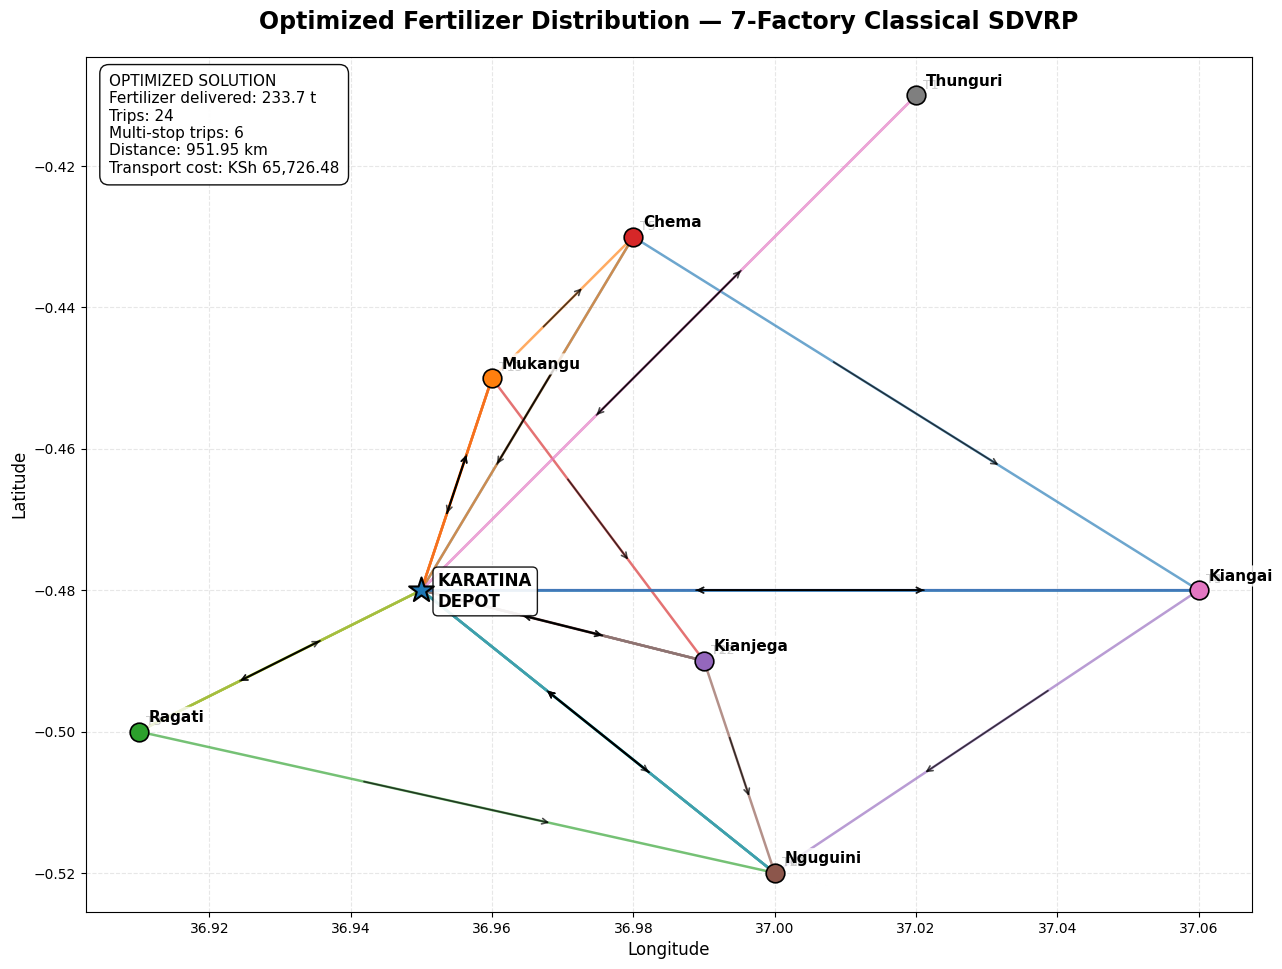

In [ ]:
# ============================================================
# QSOLVE AGRICULTURE TRACK 1
# 7-FACTORY CLASSICAL SDVRP OPTIMIZED ROUTE MAP
# ============================================================

import matplotlib.pyplot as plt

# ============================================================
# 1. LOCATIONS
# ============================================================
# IMPORTANT:
# Replace the values below with your actual longitude/latitude
# coordinates if you already have them.
#
# The values currently shown are placeholders based on your
# named locations. DO NOT use them as geographic coordinates.
#
# Format:
# "Location": (longitude, latitude)

LOCATIONS = {
    "Karatina":  (36.95, -0.48),
    "Mukangu":   (36.96, -0.45),
    "Ragati":    (36.91, -0.50),
    "Chema":     (36.98, -0.43),
    "Kianjega":  (36.99, -0.49),
    "Nguguini":  (37.00, -0.52),
    "Kiangai":   (37.06, -0.48),
    "Thunguri":  (37.02, -0.41),
}


# ============================================================
# 2. FINAL 7-FACTORY ROUTES
# ============================================================
#
# These are the routes from your actual 7-factory solution.
#
# We include the main multi-stop routes and a selection of
# single-stop routes so the complete distribution structure
# is visible.

ROUTES = [
    # Multi-stop routes
    {
        "truck": 4,
        "route": ["Karatina", "Chema", "Kiangai", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 5,
        "route": ["Karatina", "Mukangu", "Chema", "Karatina"],
        "load": "8.769 t"
    },

    {
        "truck": 7,
        "route": ["Karatina", "Ragati", "Nguguini", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 12,
        "route": ["Karatina", "Mukangu", "Kianjega", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 17,
        "route": ["Karatina", "Kiangai", "Nguguini", "Karatina"],
        "load": "7.761 t"
    },

    {
        "truck": 24,
        "route": ["Karatina", "Kianjega", "Nguguini", "Karatina"],
        "load": "10.0 t"
    },

    # Single-stop routes
    {
        "truck": 1,
        "route": ["Karatina", "Thunguri", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 2,
        "route": ["Karatina", "Kianjega", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 3,
        "route": ["Karatina", "Ragati", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 6,
        "route": ["Karatina", "Nguguini", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 9,
        "route": ["Karatina", "Kiangai", "Karatina"],
        "load": "10.0 t"
    },

    {
        "truck": 13,
        "route": ["Karatina", "Mukangu", "Karatina"],
        "load": "10.0 t"
    },
]


# ============================================================
# 3. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(13, 10))

# ============================================================
# 4. PLOT ROUTES
# ============================================================

for route_info in ROUTES:

    route = route_info["route"]
    truck = route_info["truck"]
    load = route_info["load"]

    x = [LOCATIONS[node][0] for node in route]
    y = [LOCATIONS[node][1] for node in route]

    # Plot route
    ax.plot(
        x,
        y,
        marker="o",
        linewidth=1.8,
        alpha=0.65
    )

    # Add direction arrows between consecutive stops
    for i in range(len(route) - 1):

        x1, y1 = LOCATIONS[route[i]]
        x2, y2 = LOCATIONS[route[i + 1]]

        dx = x2 - x1
        dy = y2 - y1

        ax.annotate(
            "",
            xy=(x1 + 0.65 * dx, y1 + 0.65 * dy),
            xytext=(x1 + 0.35 * dx, y1 + 0.35 * dy),
            arrowprops=dict(
                arrowstyle="->",
                lw=1.2,
                alpha=0.7
            )
        )

    # Label truck number near the middle of the route
    mid = len(route) // 2

    xm = LOCATIONS[route[mid]][0]
    ym = LOCATIONS[route[mid]][1]

    ax.annotate(
        f"T{truck}",
        xy=(xm, ym),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )


# ============================================================
# 5. PLOT DEPOT
# ============================================================

depot_x, depot_y = LOCATIONS["Karatina"]

ax.scatter(
    depot_x,
    depot_y,
    s=350,
    marker="*",
    edgecolors="black",
    linewidths=1.5,
    zorder=10
)

ax.annotate(
    "KARATINA\nDEPOT",
    xy=(depot_x, depot_y),
    xytext=(12, -12),
    textcoords="offset points",
    fontsize=12,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        alpha=0.9
    )
)


# ============================================================
# 6. PLOT FACTORIES
# ============================================================

factories = [
    "Mukangu",
    "Ragati",
    "Chema",
    "Kianjega",
    "Nguguini",
    "Kiangai",
    "Thunguri"
]

for factory in factories:

    x, y = LOCATIONS[factory]

    ax.scatter(
        x,
        y,
        s=180,
        marker="o",
        edgecolors="black",
        linewidths=1.2,
        zorder=8
    )

    ax.annotate(
        factory,
        xy=(x, y),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        )
    )


# ============================================================
# 7. TITLE
# ============================================================

ax.set_title(
    "Optimized Fertilizer Distribution — 7-Factory Classical SDVRP",
    fontsize=17,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Longitude",
    fontsize=12
)

ax.set_ylabel(
    "Latitude",
    fontsize=12
)


# ============================================================
# 8. ADD RESULT SUMMARY BOX
# ============================================================

summary_text = (
    "OPTIMIZED SOLUTION\n"
    "Fertilizer delivered: 233.7 t\n"
    "Trips: 24\n"
    "Multi-stop trips: 6\n"
    "Distance: 951.95 km\n"
    "Transport cost: KSh 65,726.48"
)

ax.text(
    0.02,
    0.98,
    summary_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="black",
        alpha=0.95
    )
)


# ============================================================
# 9. GRID / AXIS
# ============================================================

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

plt.tight_layout()


# ============================================================
# 10. SAVE
# ============================================================

plt.savefig(
    "FINAL_7_FACTORY_OPTIMIZED_ROUTE_MAP.png",
    dpi=400,
    bbox_inches="tight"
)

plt.show()